# ***Thesis Project by Group CLS***

***THESIS 1-3***

**Thesis Project**

**Group Members:**
*   Celles, Aaron Kent M.
*   Leviste, Lee Ryan A.
*   Santeco, Enrique S.

# ***Section 1. Introduction***

## **1.1 Problem Overview**

---



Large-scale global optimization (LSGO) presents a critical challenge in computational intelligence, where the "curse of dimensionality" leads to an explosive increase in local optima and a high risk of premature convergence. While foundational algorithms like Differential Evolution (DE) are robust, their dependence on crossover and random mutation may restrict guided exploration — reducing particle diversity over time and leading to premature convergence.

This notebook implements and evaluates the proposed **Diversity-Preserving Level-Based Learning Differential Evolution (DP-LLDE)** algorithm, tested against the **CEC 2017 Large-Scale Global Optimization Benchmark** across 29 benchmark functions (F1–F30, excluding deprecated F2) at **10 dimensions**.

## **1.2 Research Objectives**

---



1. Design and implement DP-LLDE, integrating sequential relative particle mutation and dynamic level-based learning into the Differential Evolution framework.
2. Evaluate DP-LLDE on the CEC 2017 benchmark suite (F1–F30) at 10 dimensions.
3. Examine convergence behavior, solution quality, and the effect of diversity-preserving strategies across unimodal, multimodal, hybrid, and composition functions.

## **1.3 Algorithm Overview - DP-LLDE**

---


DP-LLDE extends LBLDE (Qiao et al., 2022) with three core contributions:

1. **Sequential Level Assignment** — each individual is assigned a learning source level drawn randomly from {2, …, NL} on the first generation, decaying toward the elite level (level 1) in subsequent generations.
2. **Diversity-Aware Exemplar Selection** — if two exemplars e1, e2 fall below a diversity threshold, one is replaced with the most distant candidate in that level, preventing exemplar collapse.
3. **Normalized Mutation Pressure (Eq. 10):**

$$V_i = e_1 + F_i \times (e_2 - X_i) \times \frac{NL - k}{NL}$$

The factor $(NL-k)/NL$ decays to zero as $k \to NL$, naturally reducing mutation pressure as learning quality improves.

| Parameter | Value |
|-----------|-------|
| Population Size (NP) | 100 |
| Number of Levels (NL) | 4 |
| Initial μ_CR | 0.35 |
| Max FES | 10,000 × D |
| Dimensions (D) | 10 |
| Seed | 42 |

# ***Section 2. Benchmark Function Description***

## **2.1 Overview**

---


The **CEC 2017 Large-Scale Global Optimization Benchmark** (Awad et al., 2017) is a standardized suite of 30 test functions designed to evaluate optimization algorithms on complex, high-dimensional search spaces. The benchmark tests an algorithm's ability to avoid false local optima, convergence speed, and solution accuracy.

All functions are defined over the search space $[-100, 100]^D$ with their respective global optima offset by a function-specific bias value.

> **Library used:** `cec2017` by Duncan Tilley — provides the official shift vectors, rotation matrices, and shuffle permutations from the CEC 2017 specification.

## **2.2 Unimodal Function Overview**

---


Unimodal functions contain a **single global optimum and no local optima**. They are used to test the convergence speed and accuracy of an algorithm in a straightforward landscape.

| No. | Function Name | Global Optimum |
|-----|--------------|----------------|
| F1 | Shifted and Rotated Bent Cigar | 100 |
| F2 | Shifted and Rotated Sum of Different Power *(Deprecated)* | 200 |
| F3 | Shifted and Rotated Zakharov | 300 |

> **Note:** F2 is officially deprecated from the CEC 2017 benchmark but is included here for completeness as it remains implemented in the `cec2017` library.

## **2.3 Multimodal Function Overview**

---


Multimodal functions contain **multiple local optima**, making them significantly harder to solve. They are used to evaluate an algorithm's capacity to avoid premature convergence and escape false local optima.

| No. | Function Name | Global Optimum |
|-----|--------------|----------------|
| F4 | Shifted and Rotated Rosenbrock's | 400 |
| F5 | Shifted and Rotated Rastrigin's | 500 |
| F6 | Shifted and Rotated Expanded Schaffer's F6 | 600 |
| F7 | Shifted and Rotated Lunacek Bi-Rastrigin | 700 |
| F8 | Shifted and Rotated Non-Continuous Rastrigin's | 800 |
| F9 | Shifted and Rotated Levy | 900 |
| F10 | Shifted and Rotated Schwefel's | 1000 |

## **2.4 Hybrid Function Overview**

---


Hybrid functions divide the search space into several regions, each governed by a **different basic function**. They assess an algorithm's adaptability to heterogeneous landscapes and mixed search behaviors.

| No. | Component Functions | Global Optimum |
|-----|-------------------|----------------|
| F11 | Zakharov; Rosenbrock; Rastrigin | 1100 |
| F12 | Elliptic; Schwefel; Bent Cigar | 1200 |
| F13 | Bent Cigar; Rosenbrock; Bi-Rastrigin | 1300 |
| F14 | Elliptic; Ackley; Schaffer F7; Rastrigin | 1400 |
| F15 | Bent Cigar; HGBat; Rastrigin; Rosenbrock | 1500 |
| F16 | Schaffer F6; HGBat; Rosenbrock; Schwefel | 1600 |
| F17 | Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin | 1700 |
| F18 | Elliptic; Ackley; Rastrigin; HGBat; Discus | 1800 |
| F19 | Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer F6 | 1900 |
| F20 | HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer F7 | 2000 |

## **2.5 Composite Function Overview**

---


Composition functions **combine multiple shifted and rotated basic functions** into a single search space, creating highly complex and deceptive optimization landscapes. They are the most challenging category in the CEC 2017 suite and significantly test an algorithm's overall robustness and global search capability.

| No. | Component Functions | Global Optimum |
|-----|-------------------|----------------|
| F21 | Rosenbrock; Elliptic; Rastrigin | 2100 |
| F22 | Rastrigin; Griewank; Schwefel | 2200 |
| F23 | Rosenbrock; Ackley; Schwefel; Rastrigin | 2300 |
| F24 | Ackley; Elliptic; Griewank; Rastrigin | 2400 |
| F25 | Rastrigin; HappyCat; Ackley; Discus; Rosenbrock | 2500 |
| F26 | Schaffer F6; Schwefel; Griewank; Rosenbrock; Rastrigin | 2600 |
| F27 | HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer F6 | 2700 |
| F28 | Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer F6 | 2800 |
| F29 | F15; F16; F17 | 2900 |
| F30 | F15; F18; F19 | 3000 |

# ***Section 3. List of Required Libraries***

## **3.1 List of Libraries and Versions**

---



The following libraries and modules were used for optimization, benchmarking, and visualization in this project:

| Library / Module      | Purpose                                                                 | Version         |
|-----------------------|-------------------------------------------------------------------------|-----------------|
| `python`              | Core programming language                                               | 3.10+           |
| `numpy`               | Numerical computing and array operations                                | 2.0.2           |
| `matplotlib`          | Plotting and saving convergence graphs                                  | 3.10.0          |
| `cec2017`             | CEC 2017 benchmark functions (simple, hybrid, composition)              | Latest (pip)    |
| `cec2017.simple`      | Simple benchmark functions F1–F10                                       | —               |
| `cec2017.hybrid`      | Hybrid benchmark functions F11–F20                                      | —               |
| `cec2017.composition` | Composition benchmark functions F21–F30                                 | —               |
| `dpllde`              | DP-LLDE optimization algorithm (uploaded locally)                       | Custom          |
| `google.colab.files`  | File upload utility for loading `dpllde.py` into the Colab environment  | Built-in        |
| `sys`                 | Clears cached module before re-importing `dpllde.py`                    | Built-in        |

# ***Section 4. Environment Setup and Validation***





## **4.1 Installation**

Install `cec2017`

In [1]:
!pip install cec2017 --quiet

ERROR: Could not find a version that satisfies the requirement cec2017 (from versions: none)
ERROR: No matching distribution found for cec2017


## **4.2 File Validation**

Import `simple.py`, `hybrid.py`, and `composition.py` python files for benchmark functions

In [1]:
from cec2017 import simple, hybrid, composition
print('cec2017 loaded!')

cec2017 loaded!


Import `sys` control over warning messages for verification that `dpllde.py` exists

In [10]:
from google.colab import files
import sys

uploaded = files.upload()

if 'dpllde.py' in uploaded:
    if 'dpllde' in sys.modules:
        del sys.modules['dpllde']
    import dpllde
    from dpllde import DPLLDE
    print('dpllde.py uploaded and imported successfully!')
else:
    print('ERROR: Please upload a file named dpllde.py')

Saving dpllde.py to dpllde (1).py
ERROR: Please upload a file named dpllde.py


In [11]:
    import dpllde
    from dpllde import DPLLDE

# ***Section 5. Configuration and Helper Functions***

---



## **5.1 Library Imports**

Import libraries `numpy`, `matplotlib`, and `cec2017` for numerical computation, visualization, and CEC 2017 benchmark functions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from cec2017 import simple, hybrid, composition

## **5.2 Global Parameters**

Define global parameters

In [4]:
D = 10 # Change this when testing different dimensions

In [5]:
bounds = np.array([[-100.0, 100.0]] * D)
MAX_FES = 10000 * D
NP, NL, MU_CR = 100, 4, 0.35
SEED = 42

Store all results for summary table under `all_results` dict

In [6]:
all_results = {}

## **5.3 Function Definitions**

Define `make_wrapper` to adapt CEC 2017 functions to accept a 1D input array from DP-LLDE, returning a large penalty value if the output is invalid (nan/inf).


In [7]:
def make_wrapper(fn):
    """Wrap a cec2017 function (expects (1,D) input) to accept (D,) input."""
    def wrapper(x):
        val = fn(x.reshape(1, -1))
        if hasattr(val, '__len__'):
            val = float(val[0])
        else:
            val = float(val)
        return val if np.isfinite(val) else 1e18
    return wrapper

Define `run_and_plot` to execute a single DP-LLDE optimization run on a given benchmark function, print the results, store them for the summary table, and save the convergence graph.

In [14]:
def run_and_plot(fn_name, fn_eval, f_global, fn_label):
    """Run DP-LLDE on a function and plot convergence + diversity graphs."""
    print('=' * 80)
    print(f'DP-LLDE on CEC 2017 {fn_name} — Single Run')
    print('=' * 80)
    print(f'Function       : {fn_label} ({D}D)')
    print(f'Bounds         : [-100, 100]')
    print(f'Global optimum : {f_global}')

    opt = DPLLDE(
        objective_func=fn_eval,
        bounds=bounds,
        NP=NP, NL=NL, mu_CR_ini=MU_CR,
        max_fes=MAX_FES,
        seed=SEED
    )
    # ← Unpack 4 values now
    best_sol, best_fit, history, diversity_history = opt.optimize(verbose=True)

    error = abs(best_fit - f_global)
    print(f'\n{"="*80}')
    print('Results:')
    print(f'  Best Fitness           : {best_fit:.6e}')
    print(f'  Global Optimum         : {f_global:.6e}')
    print(f'  Error (|best-optimum|) : {error:.6e}')
    print(f'  Best Solution (5 dim)  : {best_sol[:5]}')
    print(f'  D^(0) (init. diversity): {opt.D_0:.4e}')
    print(f'{"="*80}')

    # Store for summary
    all_results[fn_name] = {
        'label': fn_label,
        'best_fit': best_fit,
        'f_global': f_global,
        'error': error
    }

    fes_axis = np.linspace(0, MAX_FES, len(history))
    gen_axis = np.arange(len(diversity_history))  # Generations (0, 1, 2, ...)

    # ── Two-panel figure ──────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    # Convergence curve (top) — FEs on x-axis
    ax1.plot(fes_axis, history, color='steelblue', linewidth=1.5)
    ax1.set_ylabel('Best Fitness', fontsize=12)
    ax1.set_xlabel('Function Evaluations (FEs)', fontsize=12)
    ax1.set_title(
        f'DP-LLDE — CEC 2017 {fn_name}: {fn_label} ({D}D)',
        fontsize=12
    )
    ax1.grid(True, which='both', linestyle='--', alpha=0.6)

    # Diversity curve (bottom) — Generations on x-axis
    ax2.plot(gen_axis, diversity_history, color='darkorange', linewidth=1.5)
    ax2.set_xlabel('Generation', fontsize=12)
    ax2.set_ylabel('Population Diversity\n(Mean Std Dev)', fontsize=12)
    ax2.set_title(f'Diversity Across Generations — {fn_name}', fontsize=12)
    ax2.grid(True, which='both', linestyle='--', alpha=0.6)

    plt.tight_layout()
    fname = f'convergence_{fn_name}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Graph saved as {fname}\n')

# ***Section 6. CEC2017 Benchmark Functions***

---



## **6.1 Unimodal Functions (F1-F3)**

DP-LLDE on CEC 2017 F1 — Single Run
Function       : Shifted and Rotated Bent Cigar (10D)
Bounds         : [-100, 100]
Global optimum : 100.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 1.871674e+11
Generation   10: Best = 1.145665e+10  FES =   1100  μ_F = 0.580  μ_CR = 0.349  Diversity = 1.9041e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 7.373016e+08  FES =   2100  μ_F = 0.635  μ_CR = 0.352  Diversity = 5.7959e+00  k_t = [3, 4, 2, 3]
Generation   30: Best = 7.460979e+07  FES =   3100  μ_F = 0.661  μ_CR = 0.351  Diversity = 2.4609e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 6.348839e+06  FES =   4100  μ_F = 0.685  μ_CR = 0.352  Diversity = 2.1100e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 2.552607e+06  FES =   5100  μ_F = 0.699  μ_CR = 0.346  Diversity = 2.2196e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.759662e+05  FES =   6100  μ_F = 0.709  μ_CR = 0.325  Diversity = 3.7061e+00  k_t = [2, 2, 4, 4]
Generation   70: Bes

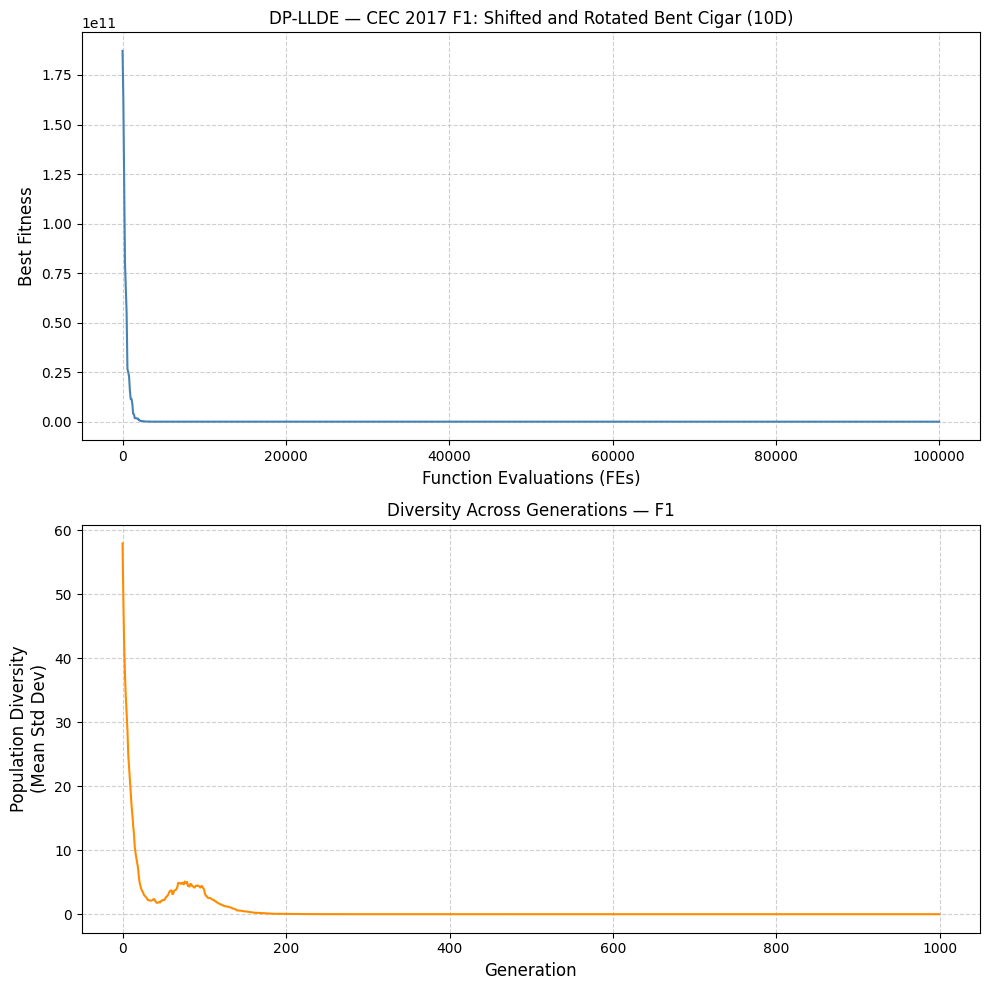

Graph saved as convergence_F1.png



In [15]:
# ============================================================
# F1 — Shifted and Rotated Bent Cigar
# ============================================================
run_and_plot('F1', make_wrapper(simple.f1), 100.0, 'Shifted and Rotated Bent Cigar')

DP-LLDE on CEC 2017 F2 — Single Run
Function       : Shifted and Rotated Sum of Different Power (Deprecated) (10D)
Bounds         : [-100, 100]
Global optimum : 200.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.603565e+14
Generation   10: Best = 3.307877e+08  FES =   1100  μ_F = 0.578  μ_CR = 0.347  Diversity = 2.7434e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 9.373572e+05  FES =   2100  μ_F = 0.625  μ_CR = 0.347  Diversity = 1.7729e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 7.764745e+04  FES =   3100  μ_F = 0.650  μ_CR = 0.351  Diversity = 1.1410e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 1.655447e+04  FES =   4100  μ_F = 0.677  μ_CR = 0.352  Diversity = 8.0397e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 6.156778e+03  FES =   5100  μ_F = 0.693  μ_CR = 0.361  Diversity = 4.7416e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 4.259731e+03  FES =   6100  μ_F = 0.709  μ_CR = 0.357  Diversity = 4.6995e+00  k_t = [2, 2, 4

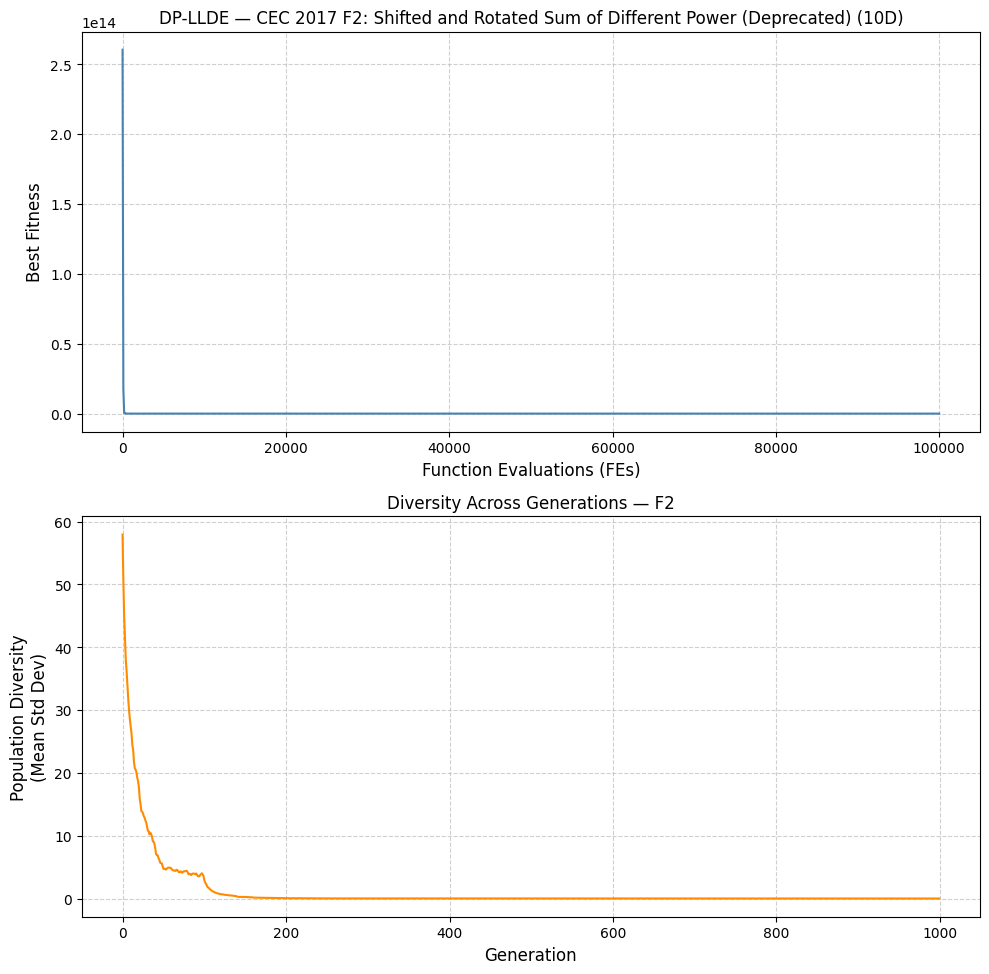

Graph saved as convergence_F2.png



In [16]:
# ============================================================
# F2 — Shifted and Rotated Sum of Different Power
# ============================================================
run_and_plot('F2', make_wrapper(simple.f2), 200.0, 'Shifted and Rotated Sum of Different Power (Deprecated)')

DP-LLDE on CEC 2017 F3 — Single Run
Function       : Shifted and Rotated Zakharov (10D)
Bounds         : [-100, 100]
Global optimum : 300.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.625937e+04
Generation   10: Best = 1.549451e+04  FES =   1100  μ_F = 0.572  μ_CR = 0.357  Diversity = 4.1542e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 6.173756e+03  FES =   2100  μ_F = 0.612  μ_CR = 0.360  Diversity = 2.4400e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.065660e+03  FES =   3100  μ_F = 0.643  μ_CR = 0.377  Diversity = 1.3908e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 9.772182e+02  FES =   4100  μ_F = 0.683  μ_CR = 0.394  Diversity = 8.0290e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 5.582284e+02  FES =   5100  μ_F = 0.706  μ_CR = 0.408  Diversity = 5.0305e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 3.605158e+02  FES =   6100  μ_F = 0.706  μ_CR = 0.411  Diversity = 2.9960e+00  k_t = [2, 2, 4, 4]
Generation   70: Best 

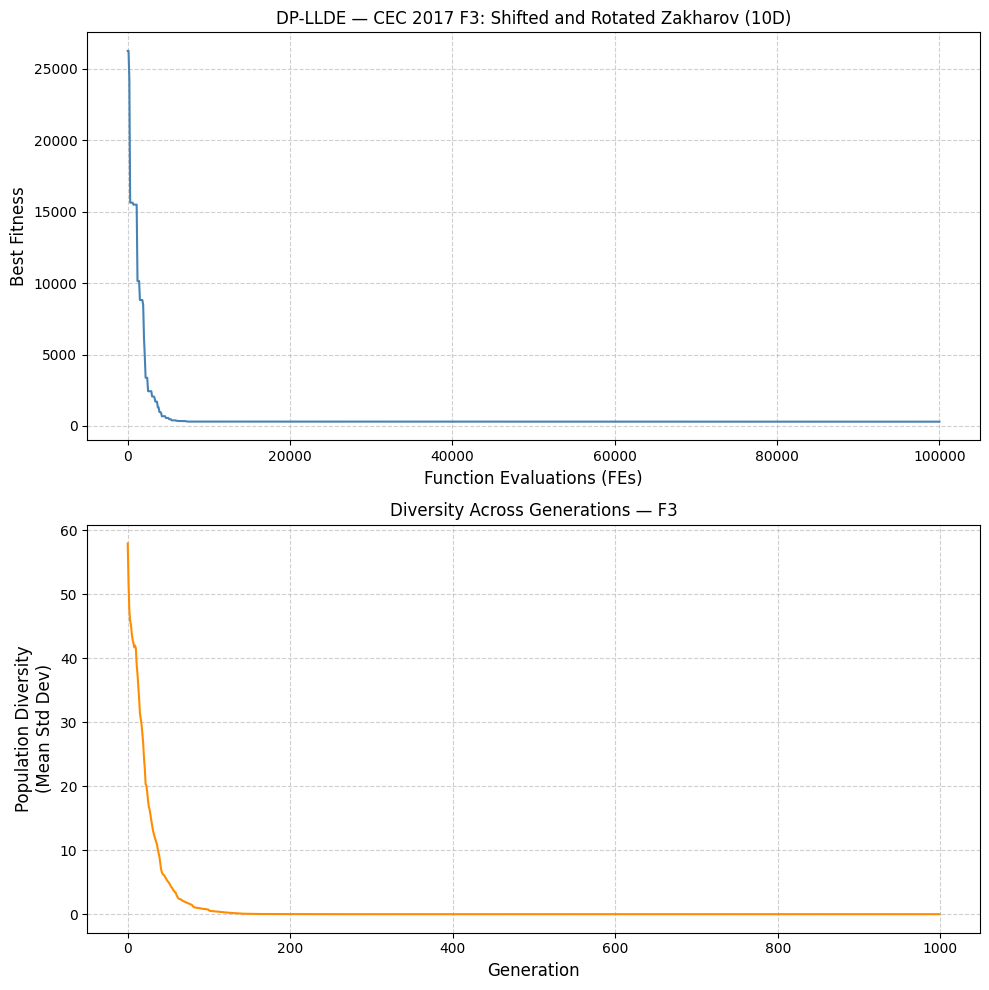

Graph saved as convergence_F3.png



In [17]:
# ============================================================
# F3 — Shifted and Rotated Zakharov
# ============================================================
run_and_plot('F3', make_wrapper(simple.f3), 300.0, 'Shifted and Rotated Zakharov')

## **6.2 Multimodal Functions (F4-F10)**

DP-LLDE on CEC 2017 F4 — Single Run
Function       : Shifted and Rotated Rosenbrock's (10D)
Bounds         : [-100, 100]
Global optimum : 400.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.004346e+03
Generation   10: Best = 5.207037e+02  FES =   1100  μ_F = 0.570  μ_CR = 0.351  Diversity = 2.1609e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 4.241273e+02  FES =   2100  μ_F = 0.611  μ_CR = 0.358  Diversity = 1.0583e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 4.053987e+02  FES =   3100  μ_F = 0.641  μ_CR = 0.368  Diversity = 5.5865e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 4.037930e+02  FES =   4100  μ_F = 0.661  μ_CR = 0.378  Diversity = 2.3553e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 4.030347e+02  FES =   5100  μ_F = 0.657  μ_CR = 0.382  Diversity = 1.9636e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 4.024577e+02  FES =   6100  μ_F = 0.668  μ_CR = 0.395  Diversity = 1.2296e+00  k_t = [2, 2, 4, 4]
Generation   70: B

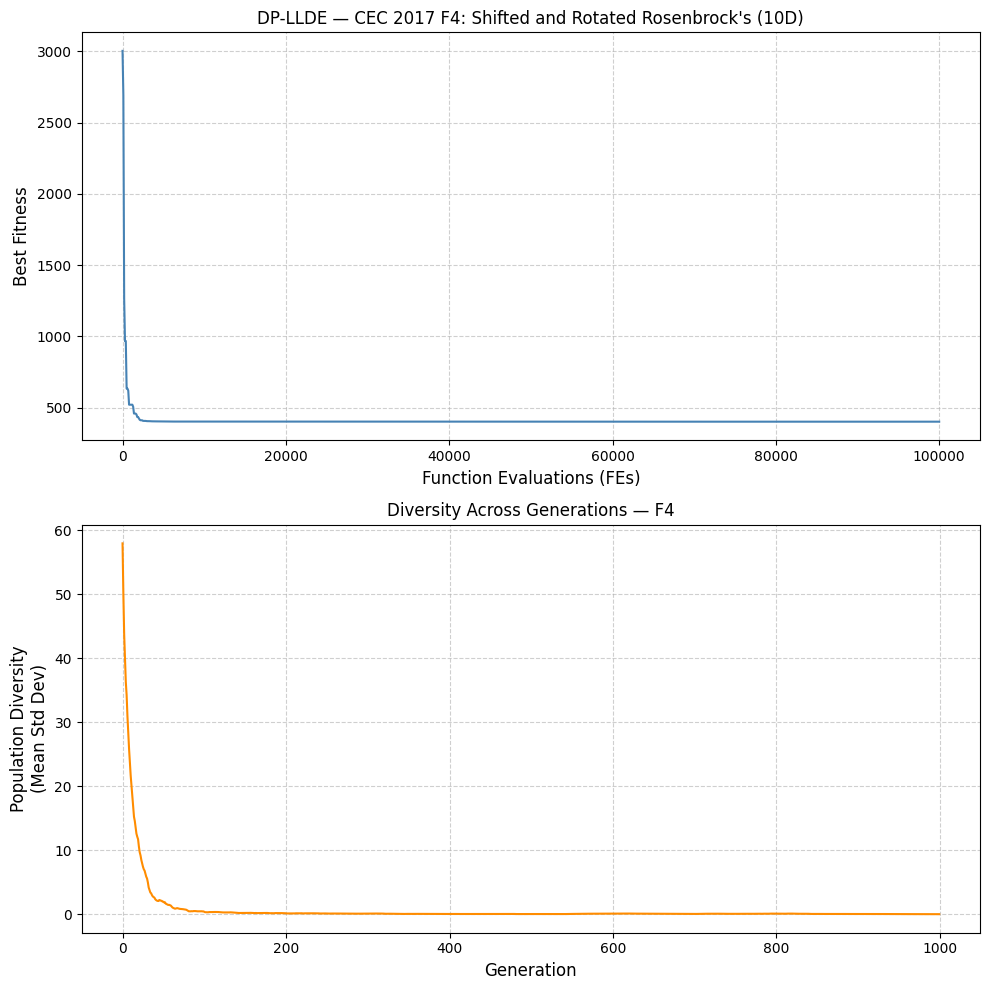

Graph saved as convergence_F4.png



In [18]:
# ============================================================
# F4 — Shifted and Rotated Rosenbrock
# ============================================================
run_and_plot('F4', make_wrapper(simple.f4), 400.0, "Shifted and Rotated Rosenbrock's")

DP-LLDE on CEC 2017 F5 — Single Run
Function       : Shifted and Rotated Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 500.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 6.377184e+02
Generation   10: Best = 5.667070e+02  FES =   1100  μ_F = 0.587  μ_CR = 0.342  Diversity = 2.7135e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 5.380114e+02  FES =   2100  μ_F = 0.657  μ_CR = 0.324  Diversity = 2.2104e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 5.380114e+02  FES =   3100  μ_F = 0.660  μ_CR = 0.303  Diversity = 1.9775e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 5.307100e+02  FES =   4100  μ_F = 0.690  μ_CR = 0.243  Diversity = 1.8886e+01  k_t = [3, 3, 4, 4]
Generation   50: Best = 5.307100e+02  FES =   5100  μ_F = 0.692  μ_CR = 0.216  Diversity = 1.7949e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 5.272589e+02  FES =   6100  μ_F = 0.699  μ_CR = 0.187  Diversity = 1.7021e+01  k_t = [3, 3, 4, 3]
Generation   70: Be

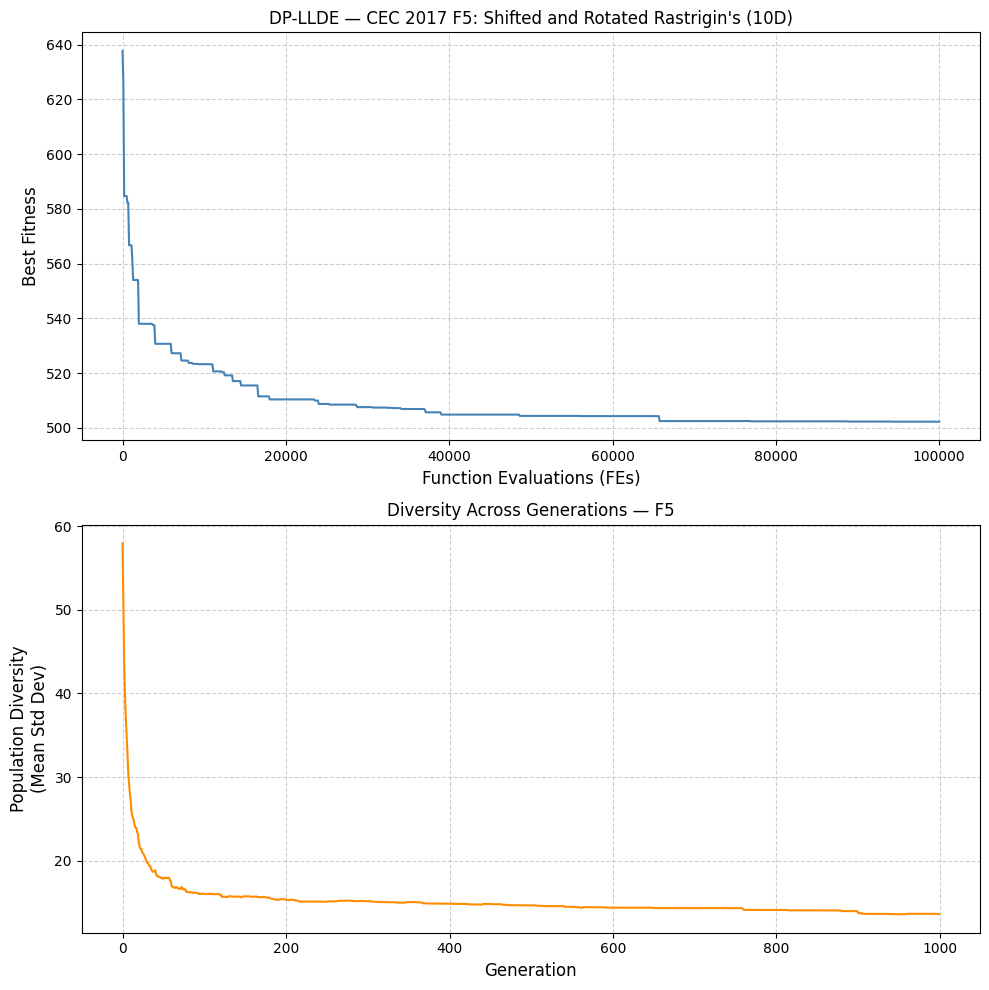

Graph saved as convergence_F5.png



In [19]:
# ============================================================
# F5 — Shifted and Rotated Rastrigin
# ============================================================
run_and_plot('F5', make_wrapper(simple.f5), 500.0, "Shifted and Rotated Rastrigin's")

DP-LLDE on CEC 2017 F6 — Single Run
Function       : Shifted and Rotated Schaffer's F7 (10D)
Bounds         : [-100, 100]
Global optimum : 600.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 7.140452e+02
Generation   10: Best = 6.287927e+02  FES =   1100  μ_F = 0.575  μ_CR = 0.346  Diversity = 2.6238e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 6.079716e+02  FES =   2100  μ_F = 0.619  μ_CR = 0.343  Diversity = 1.1591e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 6.039505e+02  FES =   3100  μ_F = 0.658  μ_CR = 0.346  Diversity = 5.0554e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 6.019566e+02  FES =   4100  μ_F = 0.700  μ_CR = 0.343  Diversity = 2.8815e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 6.013890e+02  FES =   5100  μ_F = 0.718  μ_CR = 0.337  Diversity = 1.6939e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 6.007958e+02  FES =   6100  μ_F = 0.719  μ_CR = 0.324  Diversity = 1.1129e+00  k_t = [2, 4, 2, 2]
Generation   70: 

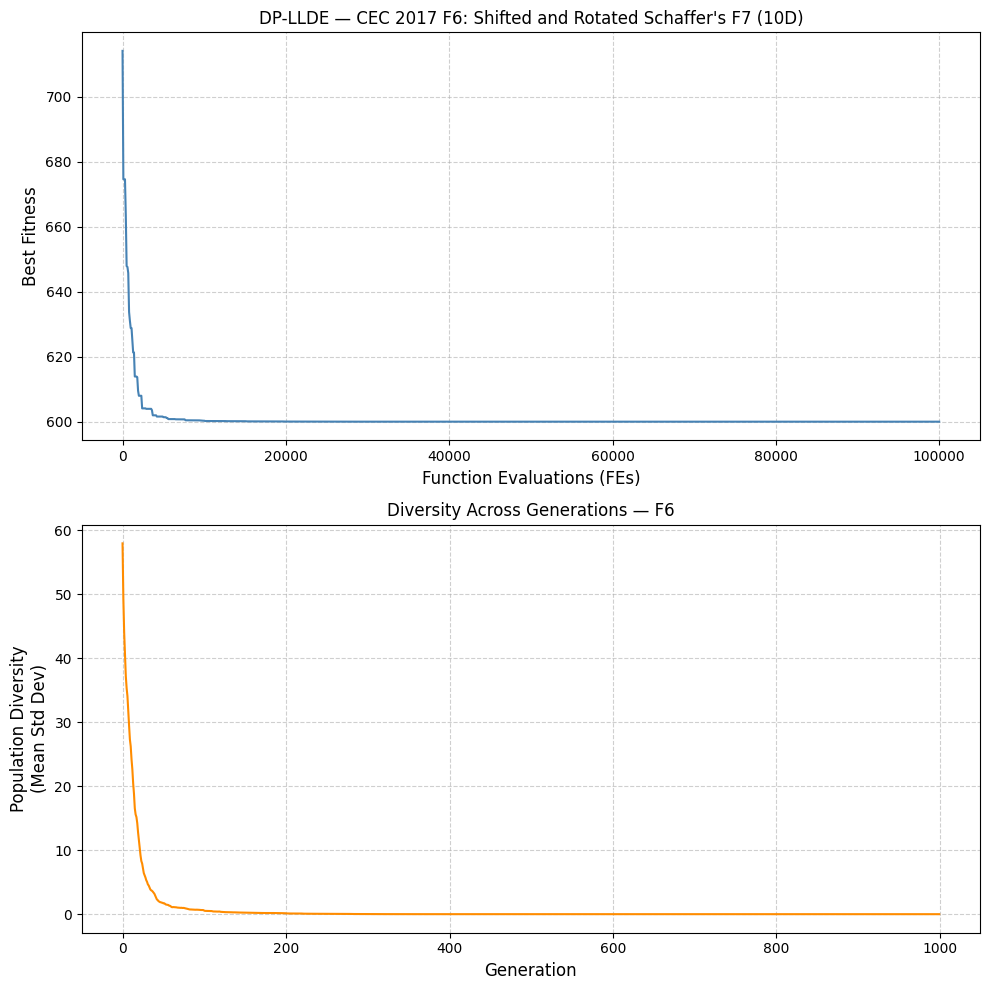

Graph saved as convergence_F6.png



In [20]:
# ============================================================
# F6 — Shifted and Rotated Schaffer's F7
# ============================================================
run_and_plot('F6', make_wrapper(simple.f6), 600.0, "Shifted and Rotated Schaffer's F7")

DP-LLDE on CEC 2017 F7 — Single Run
Function       : Shifted and Rotated Lunacek Bi-Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 700.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 1.202264e+03
Generation   10: Best = 7.953679e+02  FES =   1100  μ_F = 0.566  μ_CR = 0.350  Diversity = 1.5858e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 7.656406e+02  FES =   2100  μ_F = 0.602  μ_CR = 0.328  Diversity = 9.0948e+00  k_t = [3, 4, 2, 3]
Generation   30: Best = 7.567199e+02  FES =   3100  μ_F = 0.658  μ_CR = 0.302  Diversity = 7.7685e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 7.532509e+02  FES =   4100  μ_F = 0.636  μ_CR = 0.260  Diversity = 7.2760e+00  k_t = [4, 2, 2, 3]
Generation   50: Best = 7.446048e+02  FES =   5100  μ_F = 0.675  μ_CR = 0.239  Diversity = 7.0905e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 7.355680e+02  FES =   6100  μ_F = 0.659  μ_CR = 0.189  Diversity = 6.5390e+00  k_t = [3, 3, 2, 3]
Generati

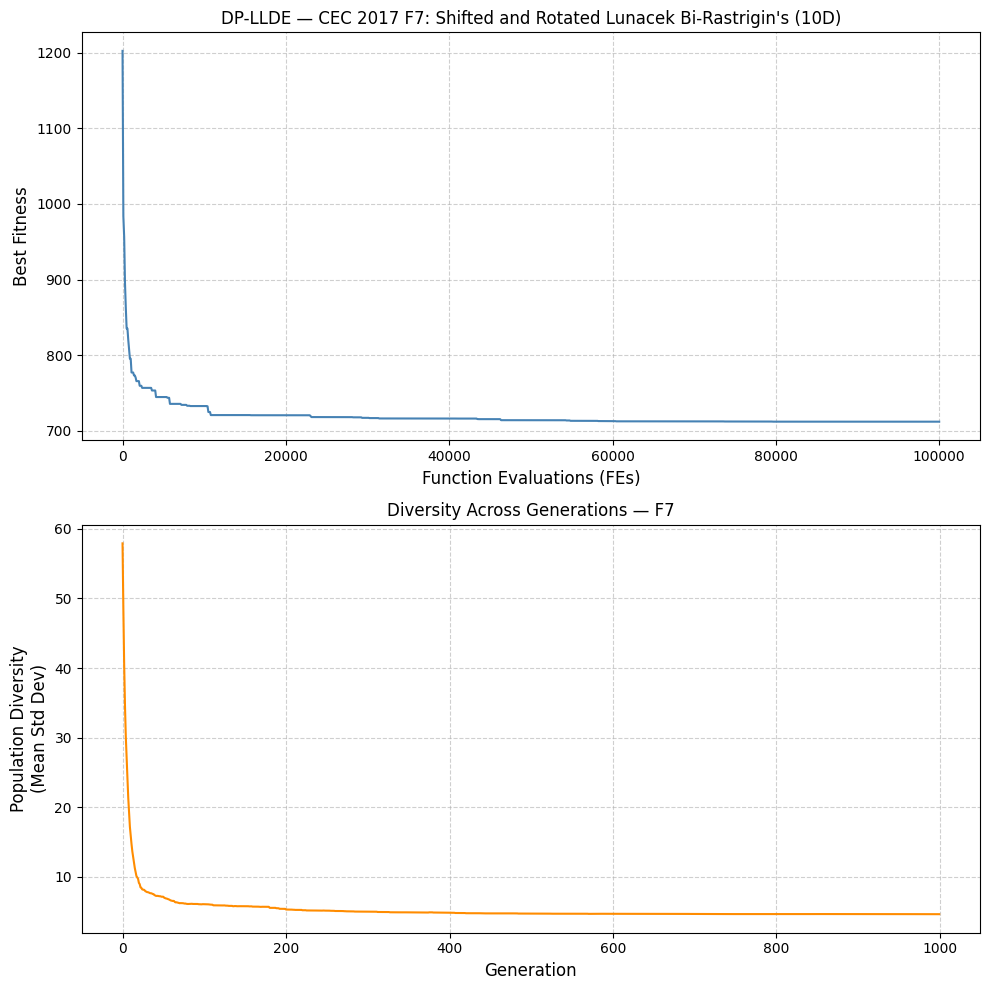

Graph saved as convergence_F7.png



In [21]:
# ============================================================
# F7 — Shifted and Rotated Lunacek Bi-Rastrigin
# ============================================================
run_and_plot('F7', make_wrapper(simple.f7), 700.0, "Shifted and Rotated Lunacek Bi-Rastrigin's")

DP-LLDE on CEC 2017 F8 — Single Run
Function       : Shifted and Rotated Non-Continuous Rastrigin's (10D)
Bounds         : [-100, 100]
Global optimum : 800.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 9.505966e+02
Generation   10: Best = 8.531139e+02  FES =   1100  μ_F = 0.562  μ_CR = 0.351  Diversity = 2.7522e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 8.475953e+02  FES =   2100  μ_F = 0.604  μ_CR = 0.334  Diversity = 2.1184e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 8.286643e+02  FES =   3100  μ_F = 0.629  μ_CR = 0.276  Diversity = 1.9001e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 8.251394e+02  FES =   4100  μ_F = 0.680  μ_CR = 0.253  Diversity = 1.7988e+01  k_t = [3, 3, 4, 4]
Generation   50: Best = 8.171760e+02  FES =   5100  μ_F = 0.745  μ_CR = 0.202  Diversity = 1.7878e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 8.171760e+02  FES =   6100  μ_F = 0.752  μ_CR = 0.160  Diversity = 1.7264e+01  k_t = [2, 4, 2, 2]
Gene

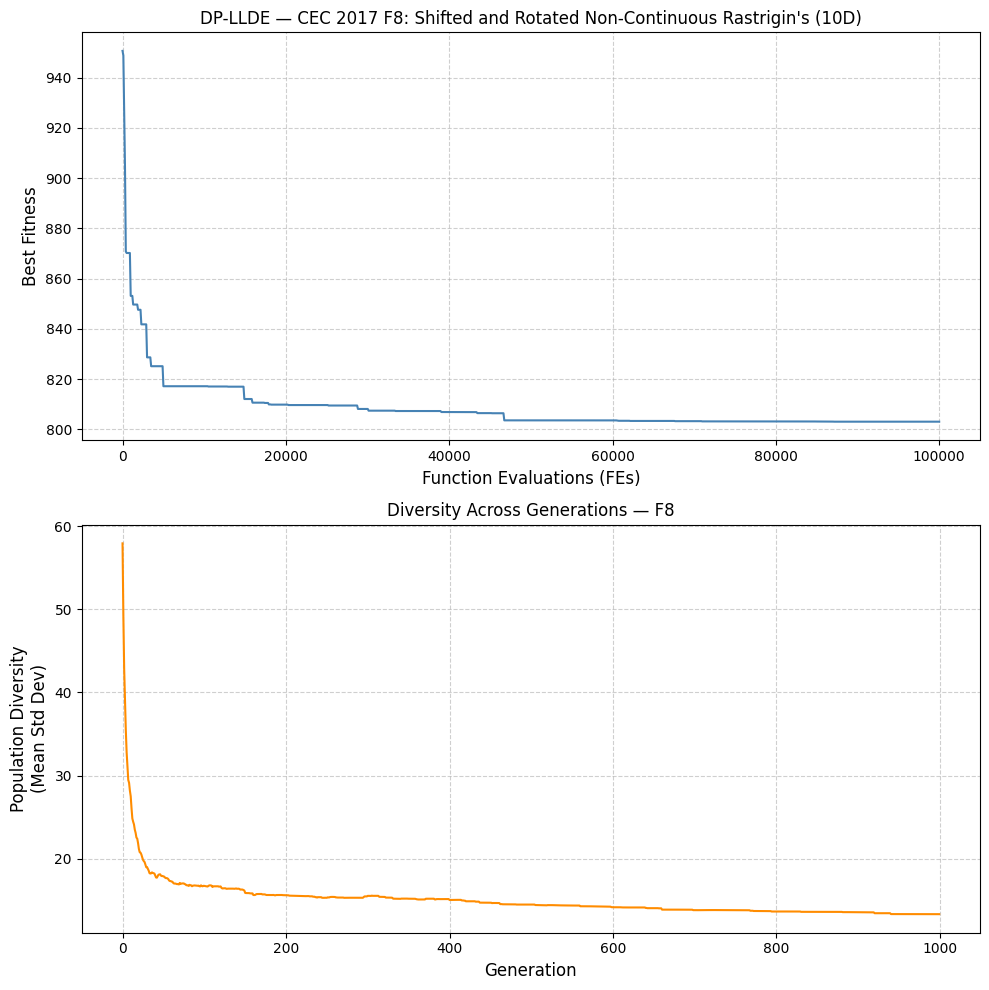

Graph saved as convergence_F8.png



In [22]:
# ============================================================
# F8 — Shifted and Rotated Non-Continuous Rastrigin
# ============================================================
run_and_plot('F8', make_wrapper(simple.f8), 800.0, "Shifted and Rotated Non-Continuous Rastrigin's")

DP-LLDE on CEC 2017 F9 — Single Run
Function       : Shifted and Rotated Levy (10D)
Bounds         : [-100, 100]
Global optimum : 900.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 6.112557e+03
Generation   10: Best = 1.141316e+03  FES =   1100  μ_F = 0.567  μ_CR = 0.350  Diversity = 2.4170e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 9.319786e+02  FES =   2100  μ_F = 0.618  μ_CR = 0.351  Diversity = 8.4492e+00  k_t = [3, 4, 2, 3]
Generation   30: Best = 9.051376e+02  FES =   3100  μ_F = 0.661  μ_CR = 0.343  Diversity = 2.8887e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 9.009171e+02  FES =   4100  μ_F = 0.674  μ_CR = 0.343  Diversity = 1.1437e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 9.003172e+02  FES =   5100  μ_F = 0.664  μ_CR = 0.341  Diversity = 7.5003e-01  k_t = [1, 1, 1, 1]
Generation   60: Best = 9.001825e+02  FES =   6100  μ_F = 0.665  μ_CR = 0.336  Diversity = 4.1028e-01  k_t = [2, 2, 4, 4]
Generation   70: Best = 9.

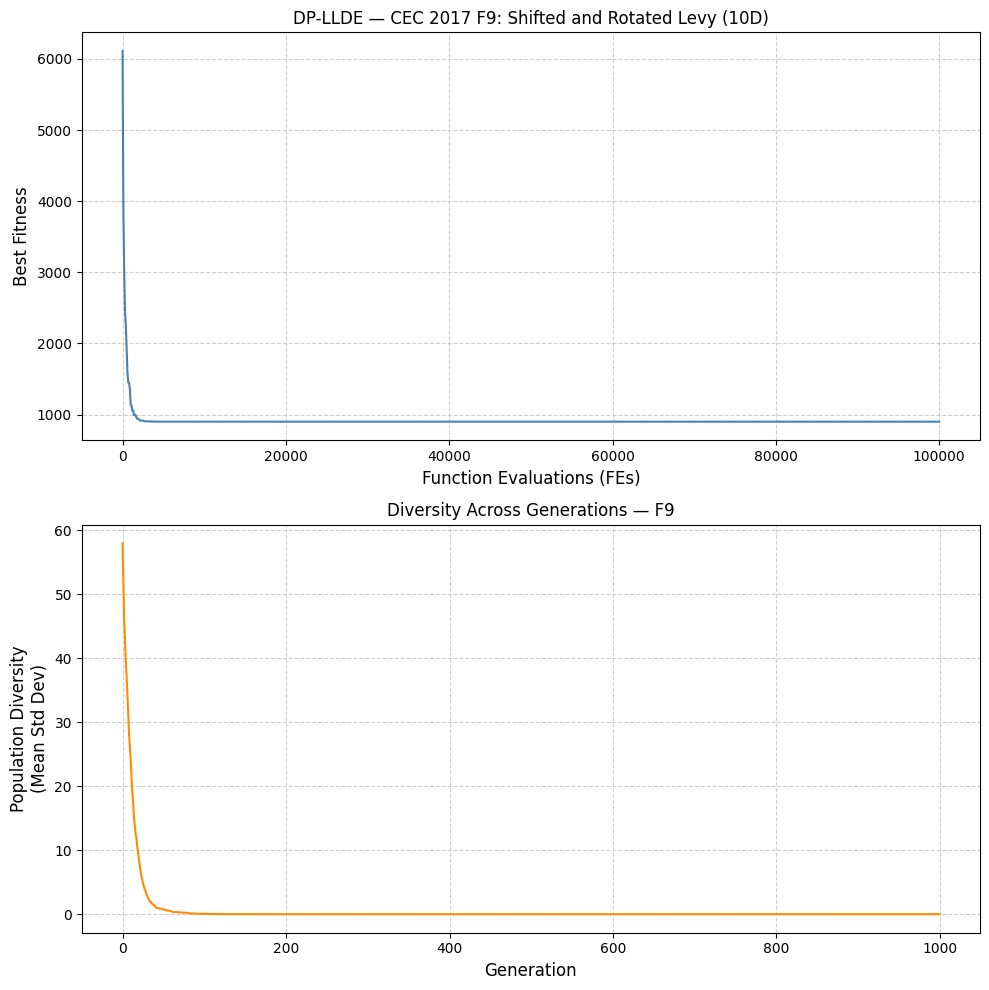

Graph saved as convergence_F9.png



In [23]:
# ============================================================
# F9 — Shifted and Rotated Levy
# ============================================================
run_and_plot('F9', make_wrapper(simple.f9), 900.0, 'Shifted and Rotated Levy')

DP-LLDE on CEC 2017 F10 — Single Run
Function       : Shifted and Rotated Schwefel's (10D)
Bounds         : [-100, 100]
Global optimum : 1000.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.749402e+03
Generation   10: Best = 3.090221e+03  FES =   1100  μ_F = 0.597  μ_CR = 0.332  Diversity = 4.7508e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 2.657155e+03  FES =   2100  μ_F = 0.662  μ_CR = 0.320  Diversity = 4.8669e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.236696e+03  FES =   3100  μ_F = 0.672  μ_CR = 0.276  Diversity = 4.7241e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.236696e+03  FES =   4100  μ_F = 0.730  μ_CR = 0.223  Diversity = 4.6825e+01  k_t = [4, 4, 3, 4]
Generation   50: Best = 2.236696e+03  FES =   5100  μ_F = 0.728  μ_CR = 0.167  Diversity = 4.5803e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 2.204884e+03  FES =   6100  μ_F = 0.723  μ_CR = 0.149  Diversity = 4.5706e+01  k_t = [3, 4, 4, 2]
Generation   70: B

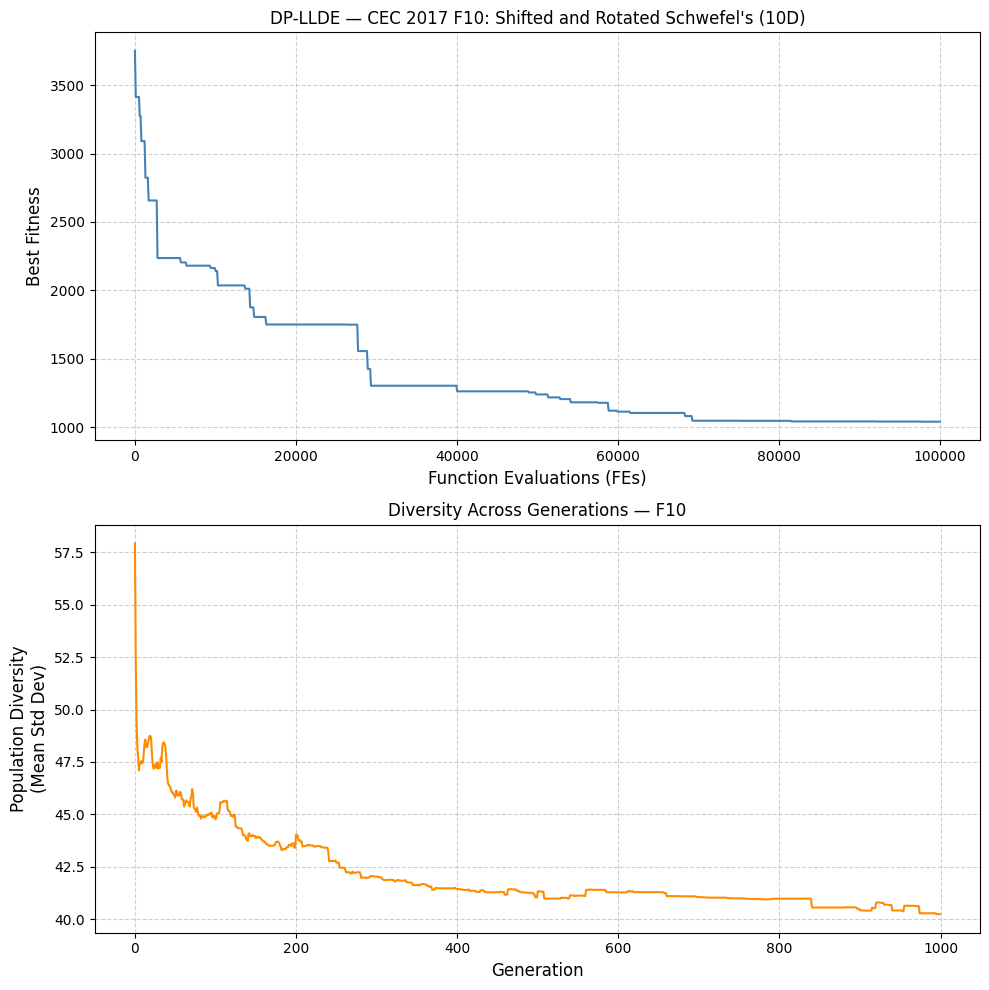

Graph saved as convergence_F10.png



In [24]:
# ============================================================
# F10 — Shifted and Rotated Schwefel
# ============================================================
run_and_plot('F10', make_wrapper(simple.f10), 1000.0, "Shifted and Rotated Schwefel's")

## **6.3 Hybrid Functions (F11-F20)**

DP-LLDE on CEC 2017 F11 — Single Run
Function       : Hybrid: Zakharov; Rosenbrock; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1100.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.292232e+04
Generation   10: Best = 1.271871e+03  FES =   1100  μ_F = 0.588  μ_CR = 0.351  Diversity = 3.0353e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 1.134212e+03  FES =   2100  μ_F = 0.635  μ_CR = 0.351  Diversity = 1.5183e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 1.118996e+03  FES =   3100  μ_F = 0.655  μ_CR = 0.345  Diversity = 1.0068e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 1.108991e+03  FES =   4100  μ_F = 0.678  μ_CR = 0.329  Diversity = 8.7750e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 1.108991e+03  FES =   5100  μ_F = 0.690  μ_CR = 0.289  Diversity = 8.3305e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.108437e+03  FES =   6100  μ_F = 0.707  μ_CR = 0.268  Diversity = 7.9392e+00  k_t = [2, 2, 4, 2]
Generatio

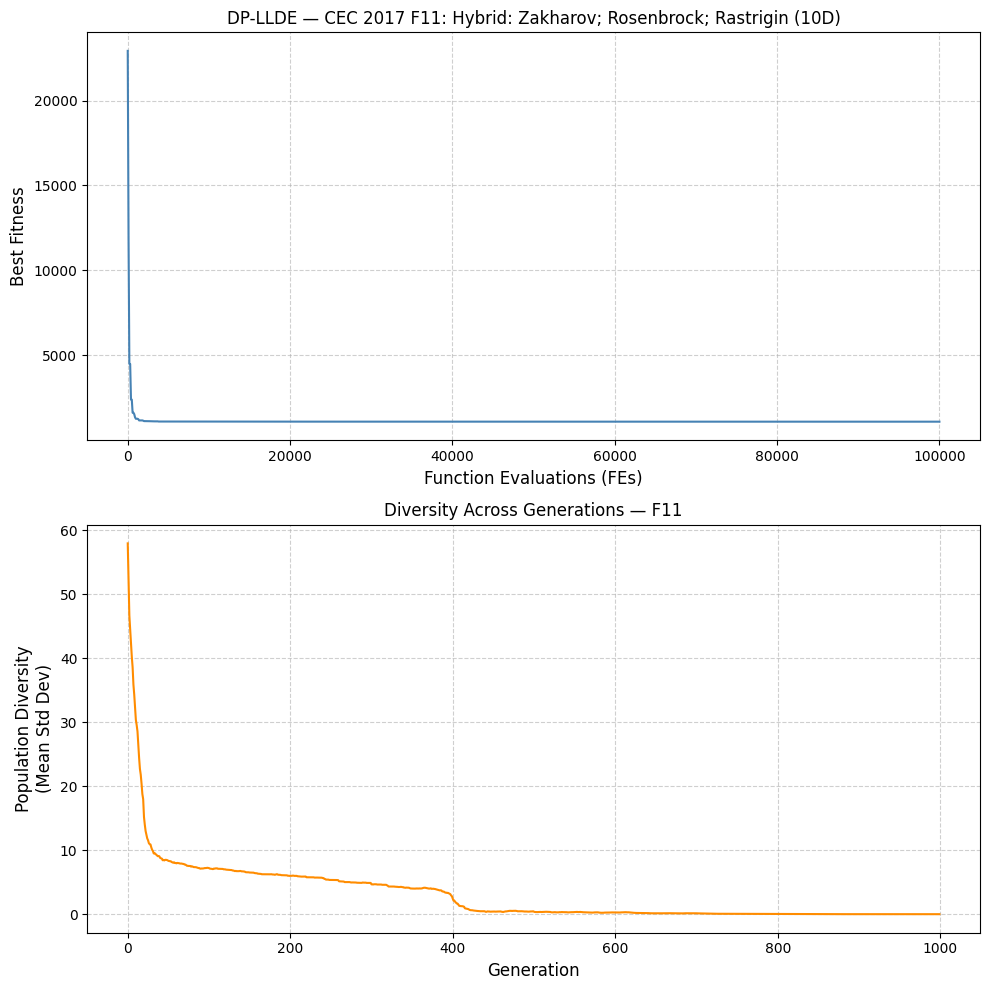

Graph saved as convergence_F11.png



In [25]:
# ============================================================
# F11 — Hybrid Function 1 (Zakharov; Rosenbrock; Rastrigin)
# ============================================================
run_and_plot('F11', make_wrapper(hybrid.f11), 1100.0, 'Hybrid: Zakharov; Rosenbrock; Rastrigin')

DP-LLDE on CEC 2017 F12 — Single Run
Function       : Hybrid: Elliptic; Schwefel; Bent Cigar (10D)
Bounds         : [-100, 100]
Global optimum : 1200.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 7.052719e+09
Generation   10: Best = 1.627111e+08  FES =   1100  μ_F = 0.573  μ_CR = 0.351  Diversity = 2.8978e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 1.917464e+07  FES =   2100  μ_F = 0.637  μ_CR = 0.348  Diversity = 2.1528e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.601435e+06  FES =   3100  μ_F = 0.671  μ_CR = 0.337  Diversity = 1.9530e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 3.248931e+05  FES =   4100  μ_F = 0.707  μ_CR = 0.340  Diversity = 1.7305e+01  k_t = [3, 3, 2, 4]
Generation   50: Best = 9.309877e+04  FES =   5100  μ_F = 0.745  μ_CR = 0.275  Diversity = 1.7237e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 3.565290e+04  FES =   6100  μ_F = 0.745  μ_CR = 0.264  Diversity = 1.7742e+01  k_t = [3, 3, 2, 4]
Generation

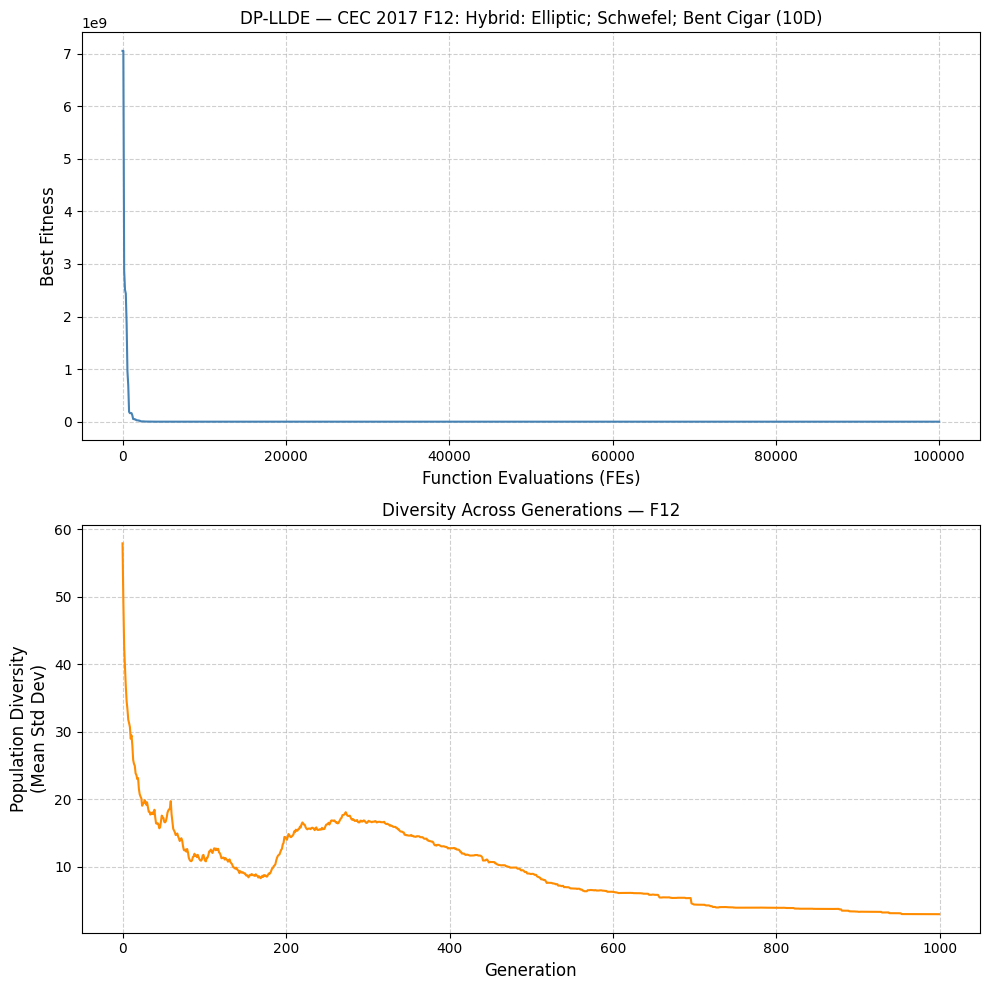

Graph saved as convergence_F12.png



In [26]:
# ============================================================
# F12 — Hybrid Function 2 (Elliptic; Schwefel; Bent Cigar)
# ============================================================
run_and_plot('F12', make_wrapper(hybrid.f12), 1200.0, 'Hybrid: Elliptic; Schwefel; Bent Cigar')

DP-LLDE on CEC 2017 F13 — Single Run
Function       : Hybrid: Bent Cigar; Rosenbrock; Bi-Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1300.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 1.212051e+09
Generation   10: Best = 1.045708e+06  FES =   1100  μ_F = 0.584  μ_CR = 0.355  Diversity = 3.2362e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 3.799438e+04  FES =   2100  μ_F = 0.642  μ_CR = 0.355  Diversity = 2.8379e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 7.581503e+03  FES =   3100  μ_F = 0.683  μ_CR = 0.343  Diversity = 2.8756e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.871346e+03  FES =   4100  μ_F = 0.730  μ_CR = 0.345  Diversity = 2.7411e+01  k_t = [3, 3, 2, 4]
Generation   50: Best = 1.772135e+03  FES =   5100  μ_F = 0.754  μ_CR = 0.357  Diversity = 2.5668e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.469520e+03  FES =   6100  μ_F = 0.766  μ_CR = 0.352  Diversity = 2.0091e+01  k_t = [2, 2, 4, 4]
Gene

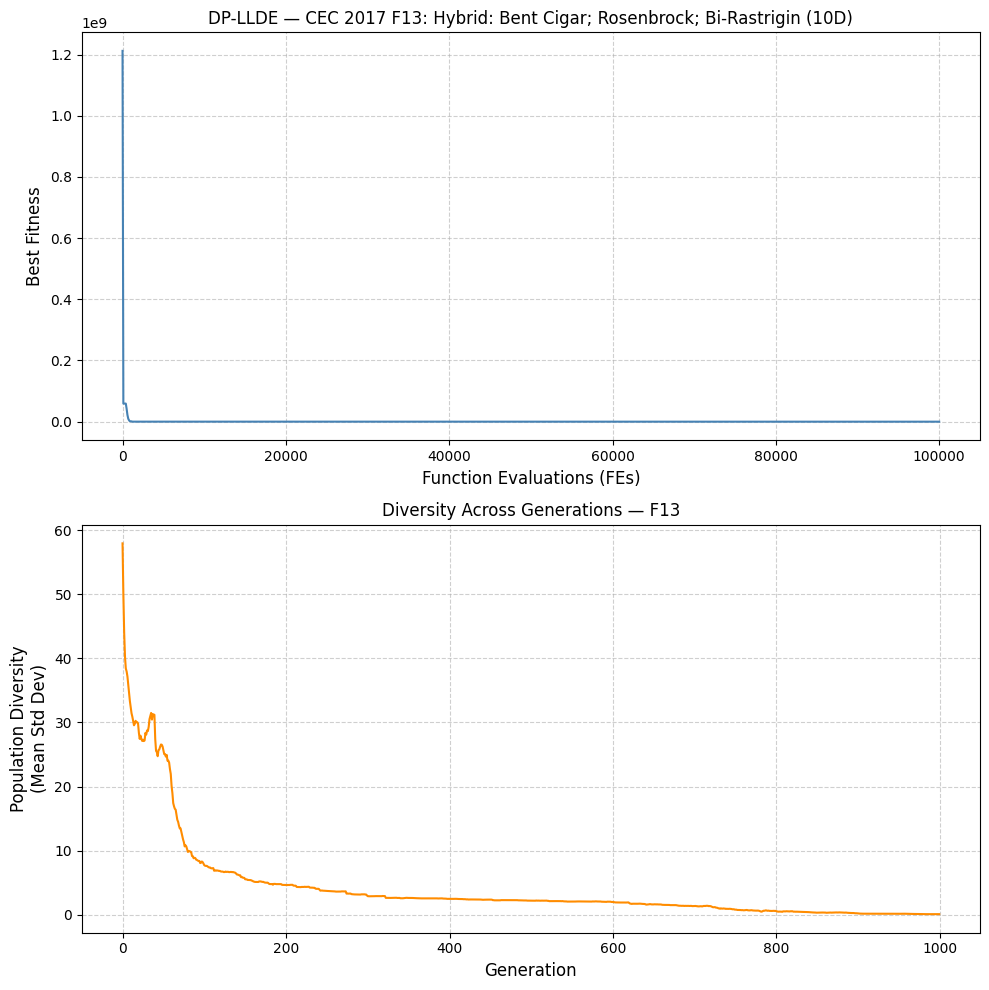

Graph saved as convergence_F13.png



In [27]:
# ============================================================
# F13 — Hybrid Function 3 (Bent Cigar; Rosenbrock; Bi-Rastrigin)
# ============================================================
run_and_plot('F13', make_wrapper(hybrid.f13), 1300.0, 'Hybrid: Bent Cigar; Rosenbrock; Bi-Rastrigin')

DP-LLDE on CEC 2017 F14 — Single Run
Function       : Hybrid: Elliptic; Ackley; Schaffer; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1400.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.917787e+04
Generation   10: Best = 1.075449e+04  FES =   1100  μ_F = 0.584  μ_CR = 0.354  Diversity = 4.0088e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 1.665269e+03  FES =   2100  μ_F = 0.650  μ_CR = 0.349  Diversity = 3.6596e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 1.489428e+03  FES =   3100  μ_F = 0.698  μ_CR = 0.351  Diversity = 2.9082e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 1.444248e+03  FES =   4100  μ_F = 0.732  μ_CR = 0.359  Diversity = 1.9936e+01  k_t = [4, 4, 3, 4]
Generation   50: Best = 1.440402e+03  FES =   5100  μ_F = 0.751  μ_CR = 0.366  Diversity = 1.7377e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.434822e+03  FES =   6100  μ_F = 0.771  μ_CR = 0.327  Diversity = 1.5720e+01  k_t = [2, 2, 4, 2]
Gen

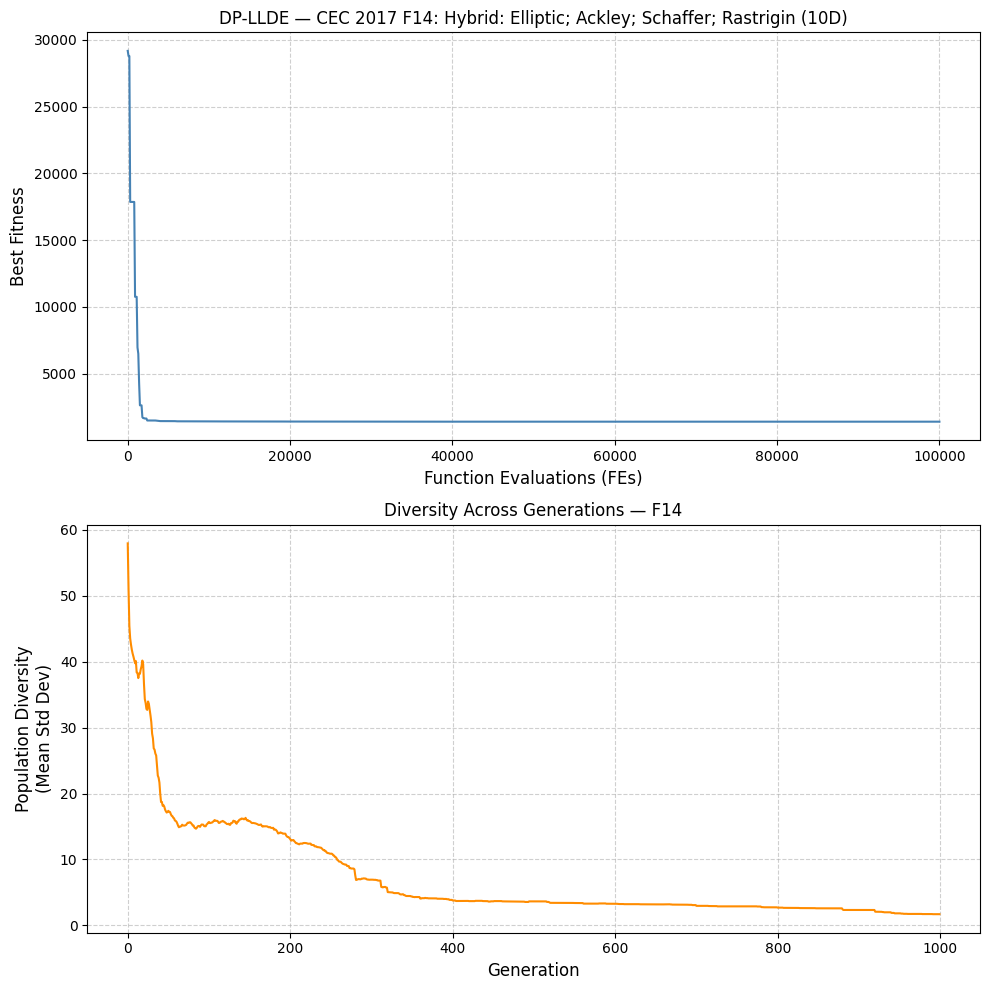

Graph saved as convergence_F14.png



In [28]:
# ============================================================
# F14 — Hybrid Function 4 (Elliptic; Ackley; Schaffer; Rastrigin)
# ============================================================
run_and_plot('F14', make_wrapper(hybrid.f14), 1400.0, 'Hybrid: Elliptic; Ackley; Schaffer; Rastrigin')

DP-LLDE on CEC 2017 F15 — Single Run
Function       : Hybrid: Bent Cigar; HGBat; Rastrigin; Rosenbrock (10D)
Bounds         : [-100, 100]
Global optimum : 1500.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.114909e+07
Generation   10: Best = 1.716556e+04  FES =   1100  μ_F = 0.595  μ_CR = 0.352  Diversity = 3.8041e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 4.154817e+03  FES =   2100  μ_F = 0.661  μ_CR = 0.351  Diversity = 3.0781e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 1.566638e+03  FES =   3100  μ_F = 0.708  μ_CR = 0.352  Diversity = 2.6521e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 1.538772e+03  FES =   4100  μ_F = 0.735  μ_CR = 0.362  Diversity = 1.8624e+01  k_t = [4, 4, 3, 4]
Generation   50: Best = 1.514788e+03  FES =   5100  μ_F = 0.760  μ_CR = 0.364  Diversity = 1.1408e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.507662e+03  FES =   6100  μ_F = 0.764  μ_CR = 0.360  Diversity = 9.0641e+00  k_t = [2, 4, 4, 4]


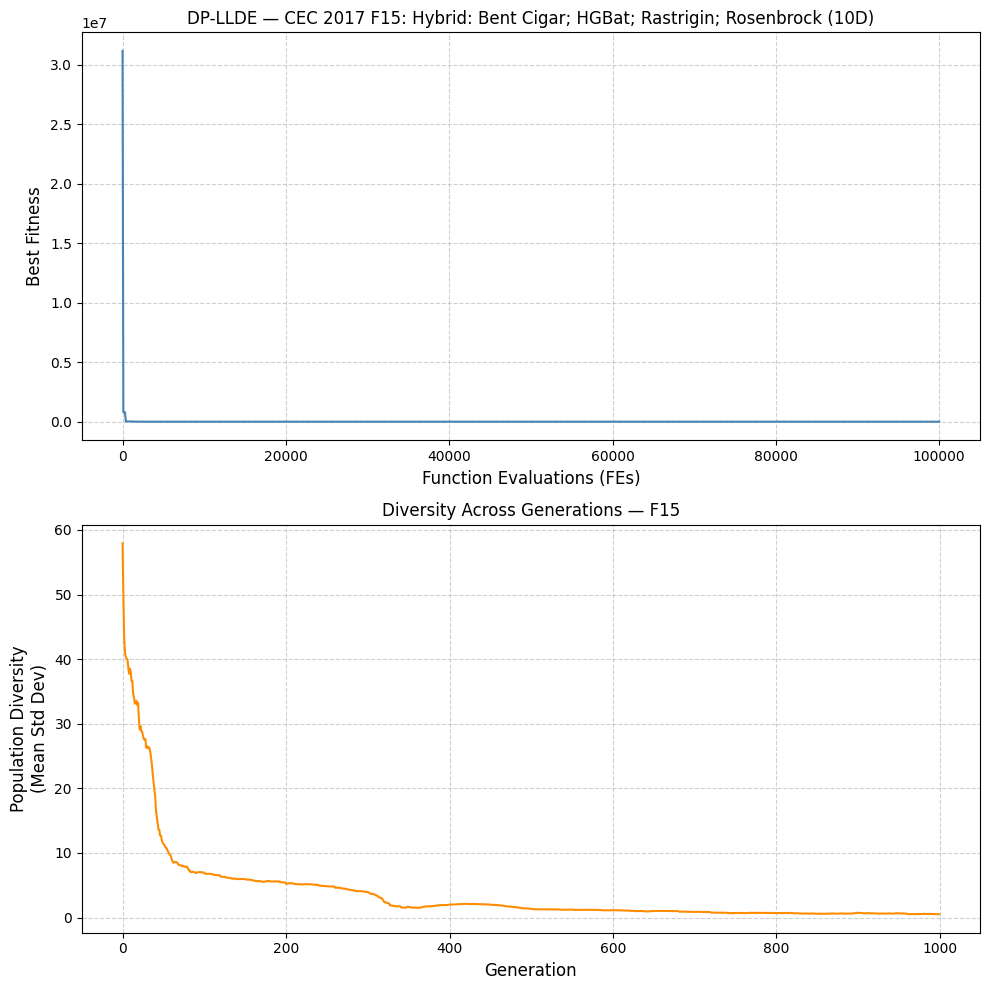

Graph saved as convergence_F15.png



In [29]:
# ============================================================
# F15 — Hybrid Function 5 (Bent Cigar; HGBat; Rastrigin; Rosenbrock)
# ============================================================
run_and_plot('F15', make_wrapper(hybrid.f15), 1500.0, 'Hybrid: Bent Cigar; HGBat; Rastrigin; Rosenbrock')

DP-LLDE on CEC 2017 F16 — Single Run
Function       : Hybrid: Schaffer; HGBat; Rosenbrock; Schwefel (10D)
Bounds         : [-100, 100]
Global optimum : 1600.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.512498e+03
Generation   10: Best = 2.092900e+03  FES =   1100  μ_F = 0.583  μ_CR = 0.331  Diversity = 3.5424e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 1.795796e+03  FES =   2100  μ_F = 0.652  μ_CR = 0.316  Diversity = 3.2154e+01  k_t = [2, 4, 2, 2]
Generation   30: Best = 1.702964e+03  FES =   3100  μ_F = 0.702  μ_CR = 0.293  Diversity = 3.1532e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 1.656168e+03  FES =   4100  μ_F = 0.716  μ_CR = 0.265  Diversity = 2.9411e+01  k_t = [3, 4, 2, 3]
Generation   50: Best = 1.651521e+03  FES =   5100  μ_F = 0.739  μ_CR = 0.252  Diversity = 2.9683e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.651512e+03  FES =   6100  μ_F = 0.755  μ_CR = 0.222  Diversity = 2.8320e+01  k_t = [3, 2, 4, 2]
Gen

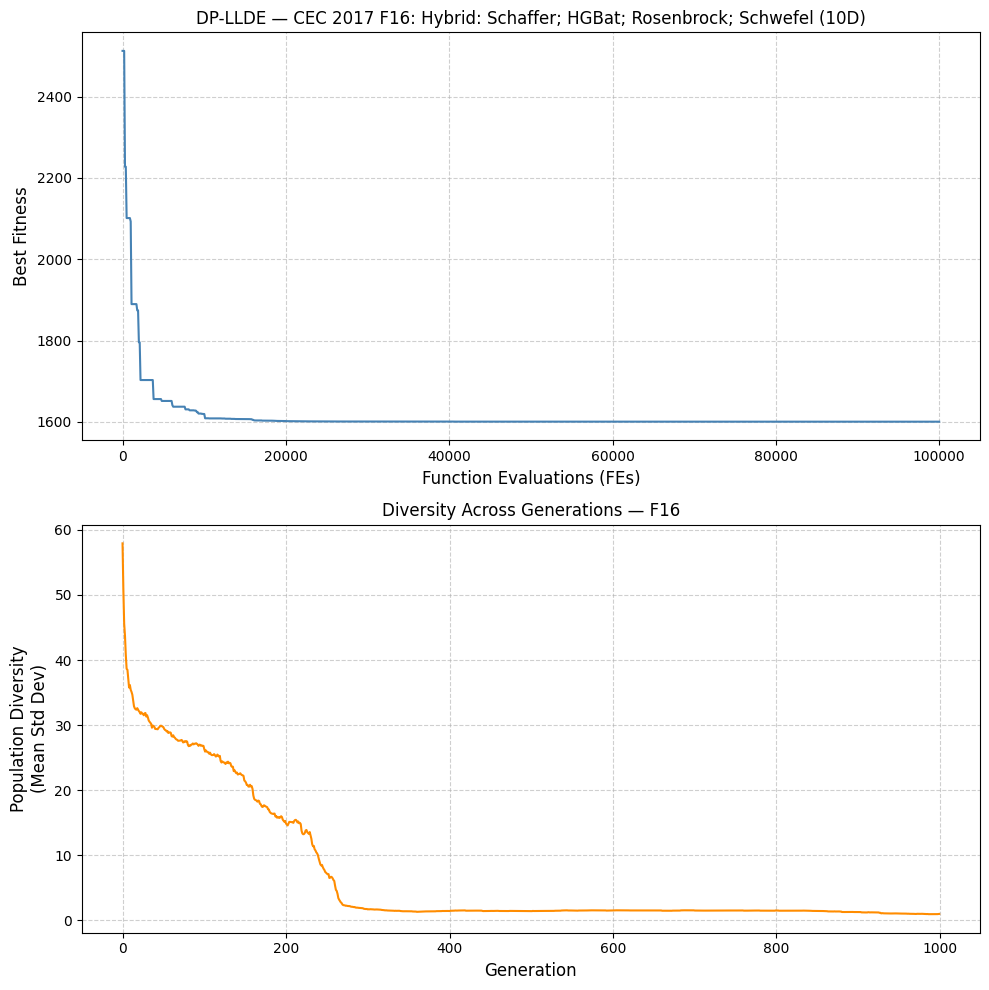

Graph saved as convergence_F16.png



In [30]:
# ============================================================
# F16 — Hybrid Function 6 (Schaffer; HGBat; Rosenbrock; Schwefel)
# ============================================================
run_and_plot('F16', make_wrapper(hybrid.f16), 1600.0, 'Hybrid: Schaffer; HGBat; Rosenbrock; Schwefel')

DP-LLDE on CEC 2017 F17 — Single Run
Function       : Hybrid: Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 1700.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.471803e+03
Generation   10: Best = 1.909686e+03  FES =   1100  μ_F = 0.576  μ_CR = 0.344  Diversity = 3.4412e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 1.805206e+03  FES =   2100  μ_F = 0.630  μ_CR = 0.335  Diversity = 3.0982e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 1.791016e+03  FES =   3100  μ_F = 0.674  μ_CR = 0.306  Diversity = 2.9771e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 1.768535e+03  FES =   4100  μ_F = 0.730  μ_CR = 0.286  Diversity = 2.9770e+01  k_t = [3, 3, 2, 4]
Generation   50: Best = 1.768535e+03  FES =   5100  μ_F = 0.768  μ_CR = 0.260  Diversity = 3.0645e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.752140e+03  FES =   6100  μ_F = 0.785  μ_CR = 0.220  Diversity = 2.9833e+01  k

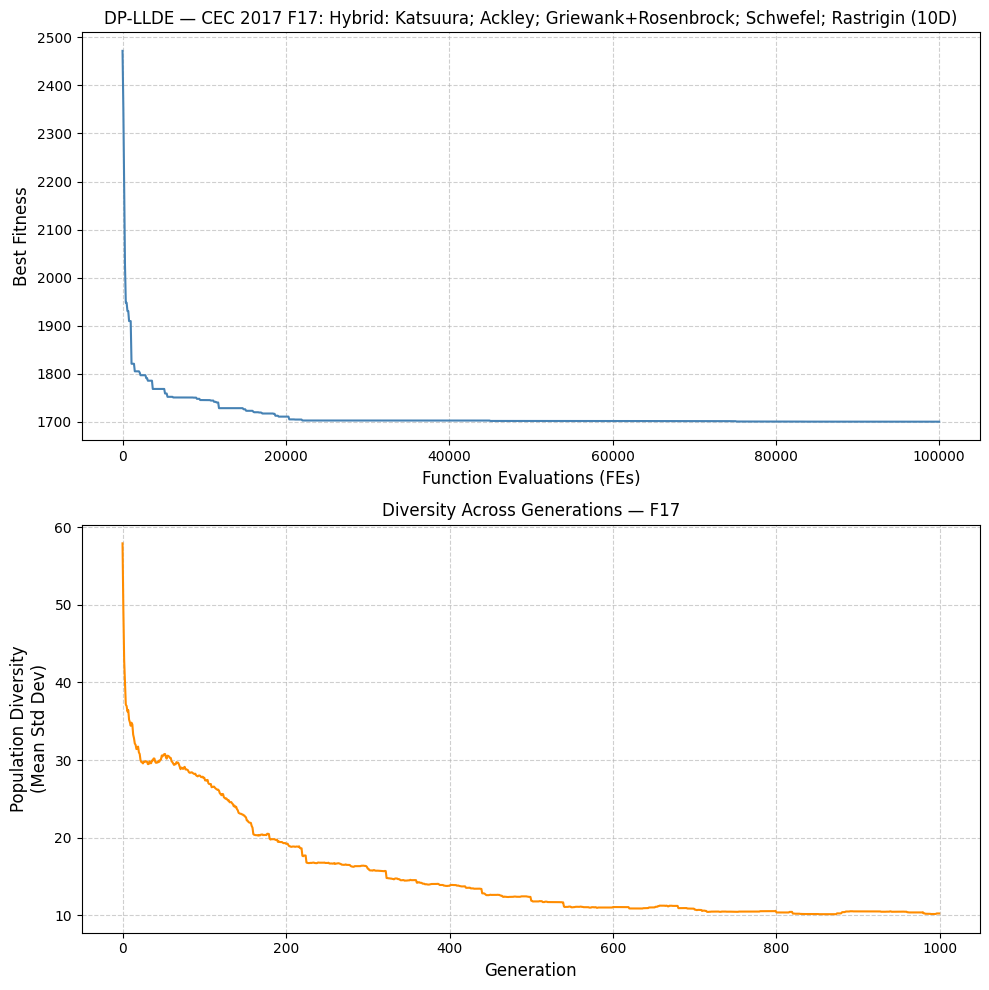

Graph saved as convergence_F17.png



In [31]:
# ============================================================
# F17 — Hybrid Function 7 (Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin)
# ============================================================
run_and_plot('F17', make_wrapper(hybrid.f17), 1700.0, 'Hybrid: Katsuura; Ackley; Griewank+Rosenbrock; Schwefel; Rastrigin')

DP-LLDE on CEC 2017 F18 — Single Run
Function       : Hybrid: Elliptic; Ackley; Rastrigin; HGBat; Discus (10D)
Bounds         : [-100, 100]
Global optimum : 1800.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 6.135676e+08
Generation   10: Best = 6.173839e+04  FES =   1100  μ_F = 0.588  μ_CR = 0.354  Diversity = 3.2488e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 6.173839e+04  FES =   2100  μ_F = 0.645  μ_CR = 0.357  Diversity = 2.8199e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 6.015107e+03  FES =   3100  μ_F = 0.679  μ_CR = 0.349  Diversity = 2.8395e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.494801e+03  FES =   4100  μ_F = 0.721  μ_CR = 0.349  Diversity = 2.4456e+01  k_t = [3, 3, 2, 4]
Generation   50: Best = 1.939301e+03  FES =   5100  μ_F = 0.759  μ_CR = 0.352  Diversity = 1.8976e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.855505e+03  FES =   6100  μ_F = 0.767  μ_CR = 0.333  Diversity = 1.6670e+01  k_t = [2, 2, 4, 4

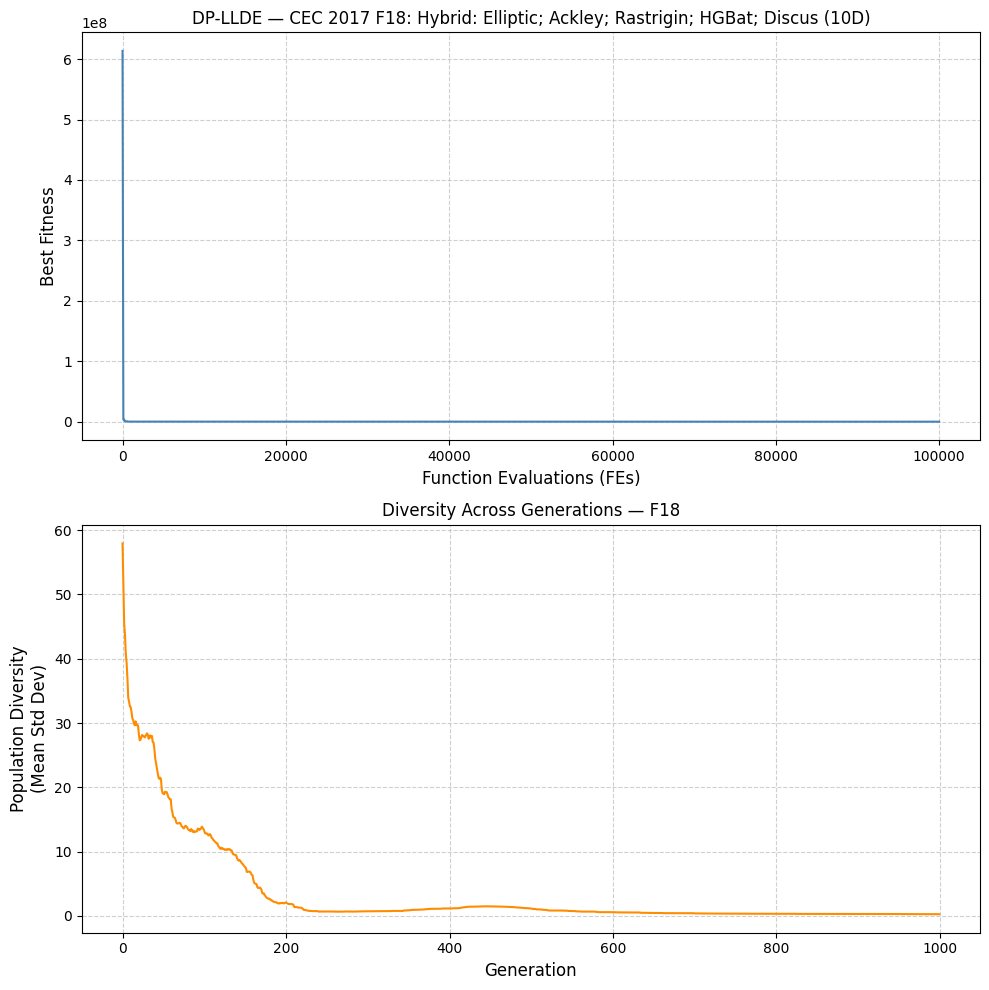

Graph saved as convergence_F18.png



In [32]:
# ============================================================
# F18 — Hybrid Function 8 (Elliptic; Ackley; Rastrigin; HGBat; Discus)
# ============================================================
run_and_plot('F18', make_wrapper(hybrid.f18), 1800.0, 'Hybrid: Elliptic; Ackley; Rastrigin; HGBat; Discus')

DP-LLDE on CEC 2017 F19 — Single Run
Function       : Hybrid: Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 1900.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.530389e+08
Generation   10: Best = 1.362757e+04  FES =   1100  μ_F = 0.588  μ_CR = 0.350  Diversity = 3.5008e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 2.425325e+03  FES =   2100  μ_F = 0.654  μ_CR = 0.340  Diversity = 3.1260e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 1.944905e+03  FES =   3100  μ_F = 0.702  μ_CR = 0.337  Diversity = 2.3865e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 1.913897e+03  FES =   4100  μ_F = 0.737  μ_CR = 0.346  Diversity = 2.0274e+01  k_t = [4, 4, 3, 4]
Generation   50: Best = 1.907341e+03  FES =   5100  μ_F = 0.767  μ_CR = 0.348  Diversity = 1.7260e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 1.905922e+03  FES =   6100  μ_F = 0.776  μ_CR = 0.322  Diversity = 1.7172

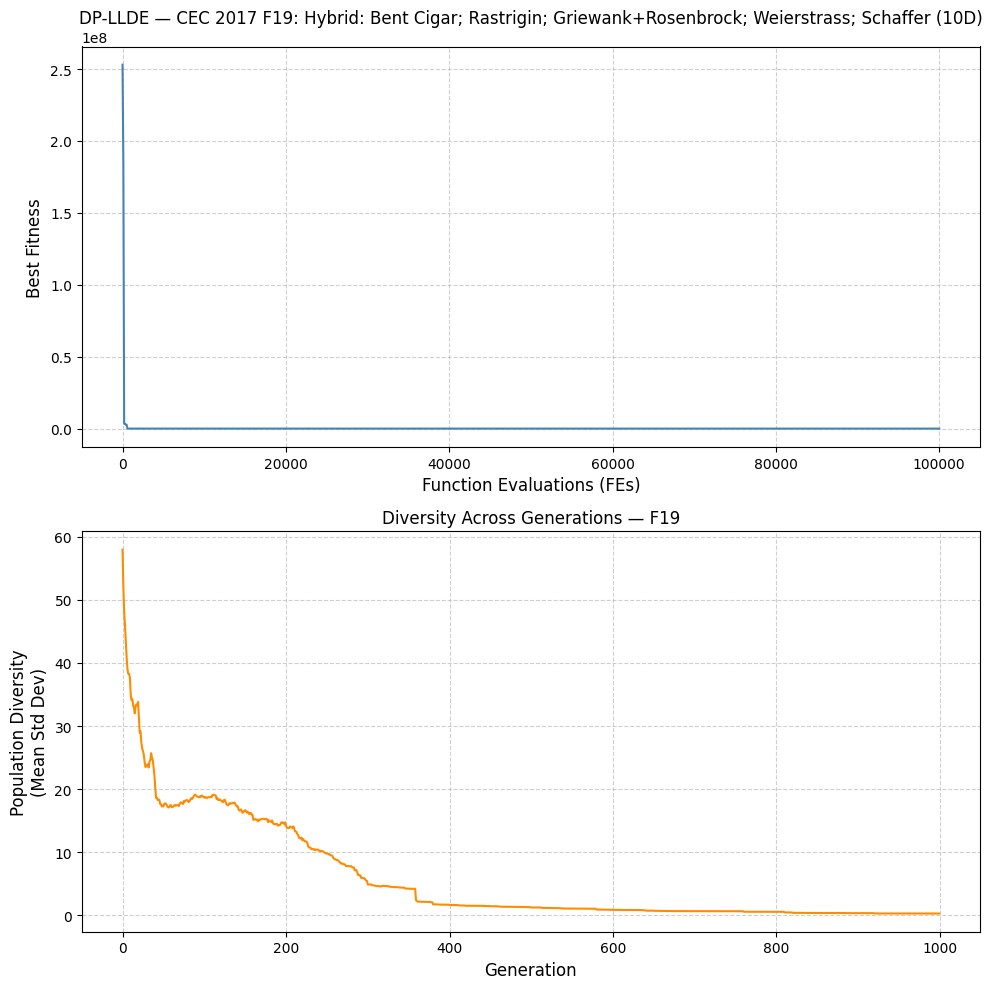

Graph saved as convergence_F19.png



In [33]:
# ============================================================
# F19 — Hybrid Function 9 (Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer)
# ============================================================
run_and_plot('F19', make_wrapper(hybrid.f19), 1900.0, 'Hybrid: Bent Cigar; Rastrigin; Griewank+Rosenbrock; Weierstrass; Schaffer')

DP-LLDE on CEC 2017 F20 — Single Run
Function       : Hybrid: HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2000.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.391561e+03
Generation   10: Best = 2.225493e+03  FES =   1100  μ_F = 0.582  μ_CR = 0.328  Diversity = 4.4557e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 2.117427e+03  FES =   2100  μ_F = 0.660  μ_CR = 0.321  Diversity = 4.0237e+01  k_t = [2, 4, 2, 2]
Generation   30: Best = 2.095462e+03  FES =   3100  μ_F = 0.728  μ_CR = 0.303  Diversity = 3.7668e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.059318e+03  FES =   4100  μ_F = 0.778  μ_CR = 0.302  Diversity = 3.5774e+01  k_t = [3, 4, 2, 3]
Generation   50: Best = 2.042947e+03  FES =   5100  μ_F = 0.824  μ_CR = 0.294  Diversity = 3.3518e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 2.039710e+03  FES =   6100  μ_F = 0.848  μ_CR = 0.260  Diversity = 2.9903e+01  k_

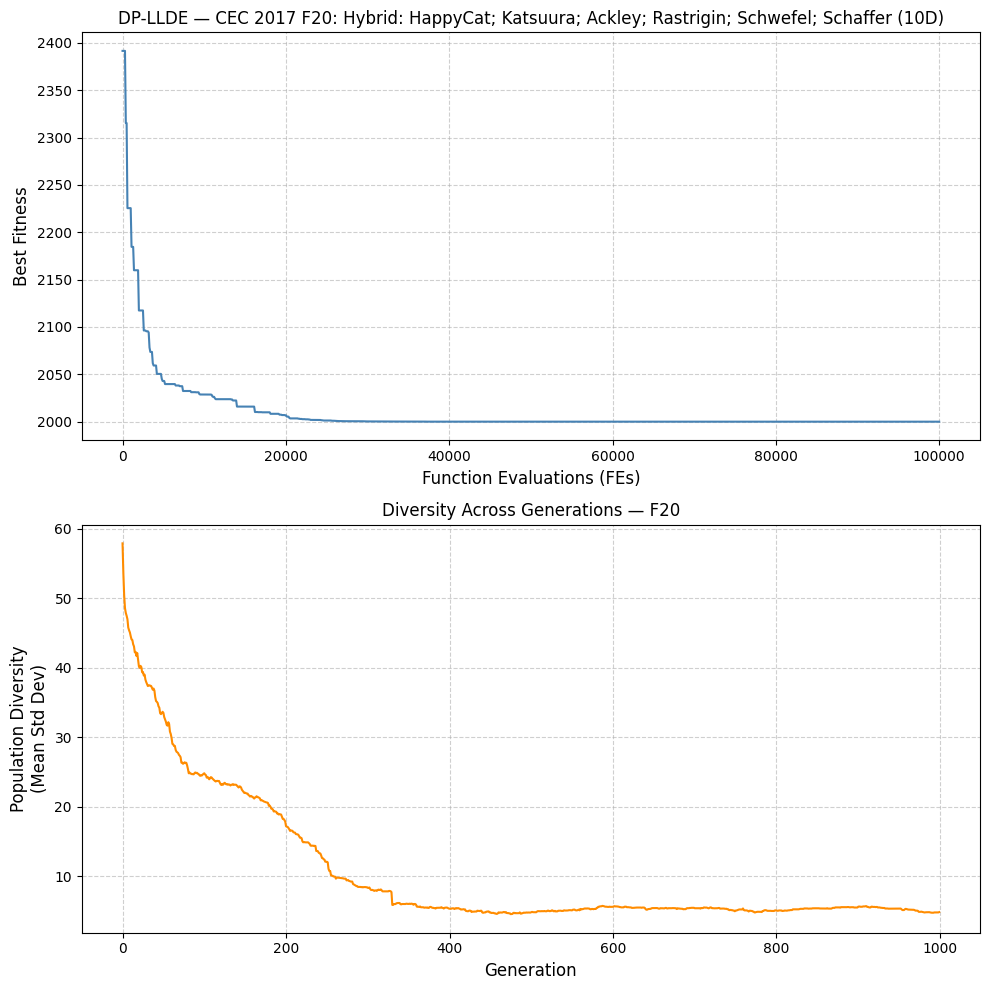

Graph saved as convergence_F20.png



In [34]:
# ============================================================
# F20 — Hybrid Function 10 (HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer)
# ============================================================
run_and_plot('F20', make_wrapper(hybrid.f20), 2000.0, 'Hybrid: HappyCat; Katsuura; Ackley; Rastrigin; Schwefel; Schaffer')

## **6.4 Composite Functions (F21-F30)**

DP-LLDE on CEC 2017 F21 — Single Run
Function       : Composition: Rosenbrock; Elliptic; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2100.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.446690e+03
Generation   10: Best = 2.310034e+03  FES =   1100  μ_F = 0.583  μ_CR = 0.347  Diversity = 3.2716e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 2.278833e+03  FES =   2100  μ_F = 0.622  μ_CR = 0.339  Diversity = 2.8158e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.237480e+03  FES =   3100  μ_F = 0.674  μ_CR = 0.287  Diversity = 2.7997e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.237480e+03  FES =   4100  μ_F = 0.690  μ_CR = 0.261  Diversity = 2.6939e+01  k_t = [3, 3, 4, 4]
Generation   50: Best = 2.231671e+03  FES =   5100  μ_F = 0.702  μ_CR = 0.256  Diversity = 2.7479e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 2.227785e+03  FES =   6100  μ_F = 0.643  μ_CR = 0.202  Diversity = 2.7784e+01  k_t = [3, 3, 2, 3]
Gene

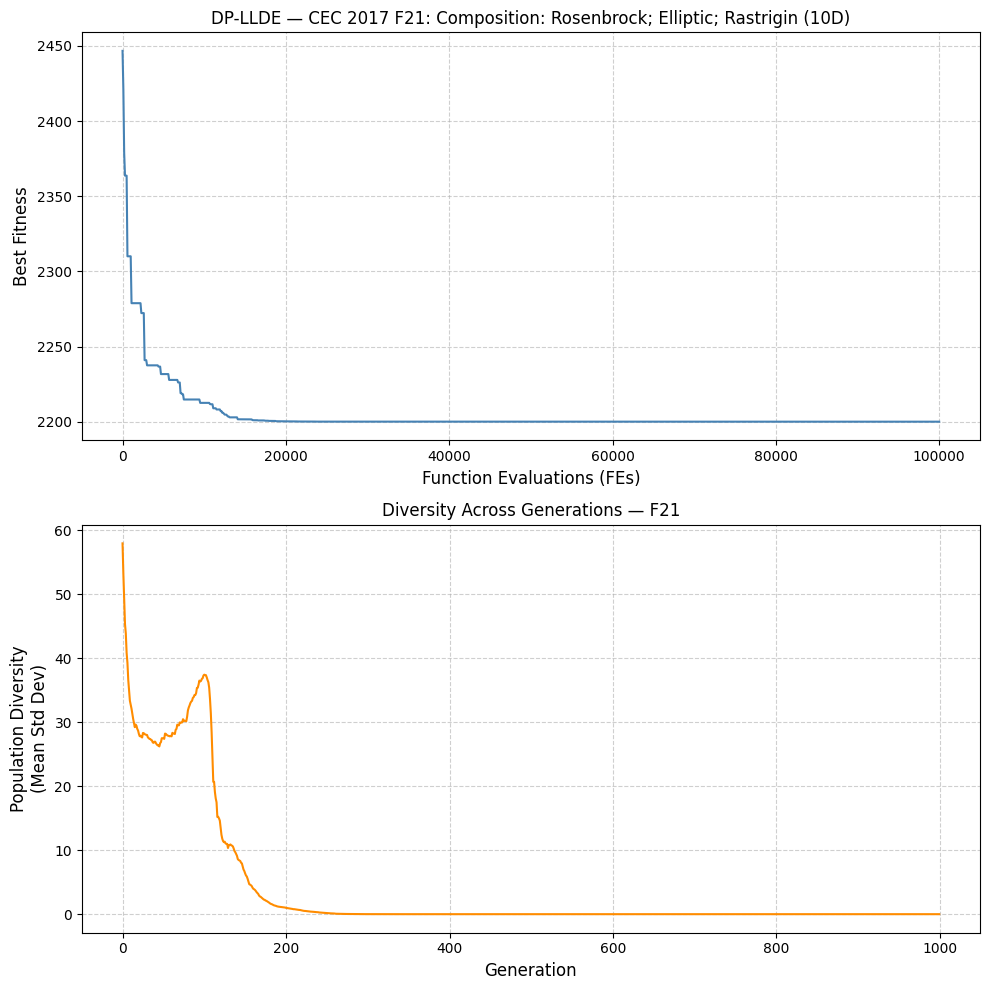

Graph saved as convergence_F21.png



In [35]:
# ============================================================
# F21 — Composition Function 1 (Rosenbrock; Elliptic; Rastrigin)
# ============================================================
run_and_plot('F21', make_wrapper(composition.f21), 2100.0, 'Composition: Rosenbrock; Elliptic; Rastrigin')

DP-LLDE on CEC 2017 F22 — Single Run
Function       : Composition: Rastrigin; Griewank; Schwefel (10D)
Bounds         : [-100, 100]
Global optimum : 2200.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.528003e+03
Generation   10: Best = 2.399917e+03  FES =   1100  μ_F = 0.578  μ_CR = 0.353  Diversity = 1.9860e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 2.319026e+03  FES =   2100  μ_F = 0.619  μ_CR = 0.356  Diversity = 5.2010e+00  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.311166e+03  FES =   3100  μ_F = 0.656  μ_CR = 0.358  Diversity = 1.5548e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.305764e+03  FES =   4100  μ_F = 0.666  μ_CR = 0.372  Diversity = 8.6435e-01  k_t = [3, 3, 2, 4]
Generation   50: Best = 2.301901e+03  FES =   5100  μ_F = 0.650  μ_CR = 0.348  Diversity = 7.6769e-01  k_t = [1, 1, 1, 1]
Generation   60: Best = 2.301901e+03  FES =   6100  μ_F = 0.642  μ_CR = 0.297  Diversity = 7.2439e-01  k_t = [2, 2, 4, 4]
Genera

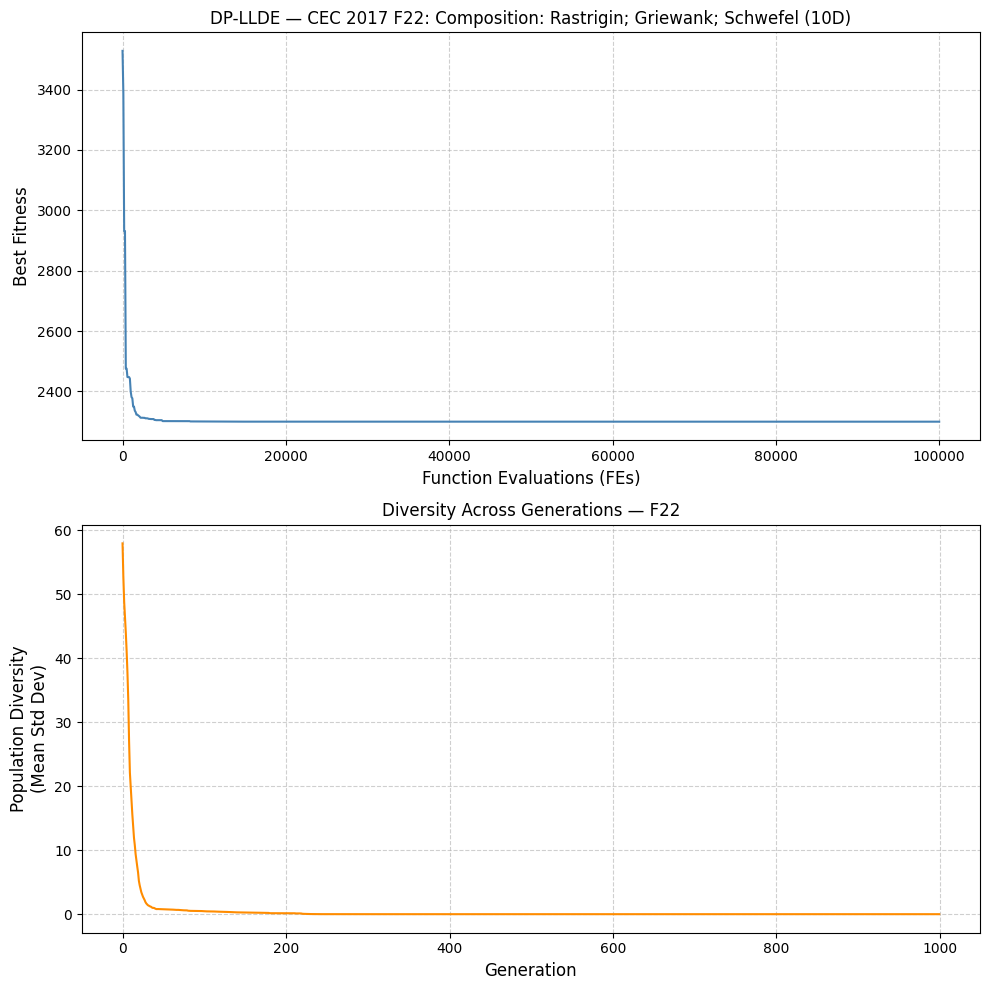

Graph saved as convergence_F22.png



In [36]:
# ============================================================
# F22 — Composition Function 2 (Rastrigin; Griewank; Schwefel)
# ============================================================
run_and_plot('F22', make_wrapper(composition.f22), 2200.0, 'Composition: Rastrigin; Griewank; Schwefel')

DP-LLDE on CEC 2017 F23 — Single Run
Function       : Composition: Rosenbrock; Ackley; Schwefel; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2300.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.773921e+03
Generation   10: Best = 2.678874e+03  FES =   1100  μ_F = 0.593  μ_CR = 0.351  Diversity = 2.8216e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 2.651353e+03  FES =   2100  μ_F = 0.631  μ_CR = 0.344  Diversity = 2.0842e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.643389e+03  FES =   3100  μ_F = 0.659  μ_CR = 0.316  Diversity = 1.9091e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.640096e+03  FES =   4100  μ_F = 0.697  μ_CR = 0.292  Diversity = 1.7992e+01  k_t = [3, 3, 2, 4]
Generation   50: Best = 2.640096e+03  FES =   5100  μ_F = 0.723  μ_CR = 0.265  Diversity = 1.7341e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 2.630197e+03  FES =   6100  μ_F = 0.734  μ_CR = 0.211  Diversity = 1.7130e+01  k_t = [3, 3, 4,

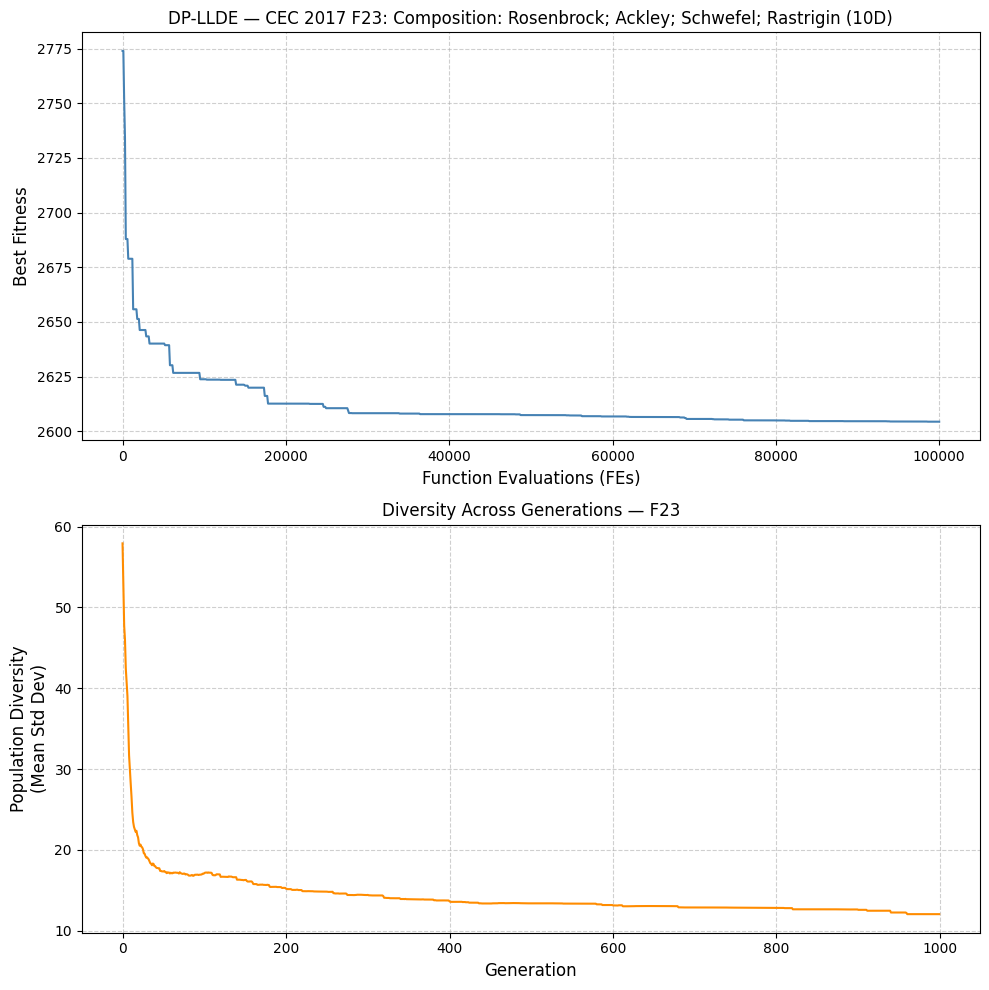

Graph saved as convergence_F23.png



In [37]:
# ============================================================
# F23 — Composition Function 3 (Rosenbrock; Ackley; Schwefel; Rastrigin)
# ============================================================
run_and_plot('F23', make_wrapper(composition.f23), 2300.0, 'Composition: Rosenbrock; Ackley; Schwefel; Rastrigin')

DP-LLDE on CEC 2017 F24 — Single Run
Function       : Composition: Ackley; Elliptic; Griewank; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2400.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 2.997998e+03
Generation   10: Best = 2.812275e+03  FES =   1100  μ_F = 0.591  μ_CR = 0.349  Diversity = 2.4795e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 2.778736e+03  FES =   2100  μ_F = 0.638  μ_CR = 0.340  Diversity = 1.8120e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.776240e+03  FES =   3100  μ_F = 0.678  μ_CR = 0.330  Diversity = 1.5938e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.764085e+03  FES =   4100  μ_F = 0.715  μ_CR = 0.287  Diversity = 1.4678e+01  k_t = [3, 3, 2, 4]
Generation   50: Best = 2.756150e+03  FES =   5100  μ_F = 0.733  μ_CR = 0.244  Diversity = 1.4519e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 2.754124e+03  FES =   6100  μ_F = 0.753  μ_CR = 0.237  Diversity = 1.4212e+01  k_t = [3, 3, 2, 4

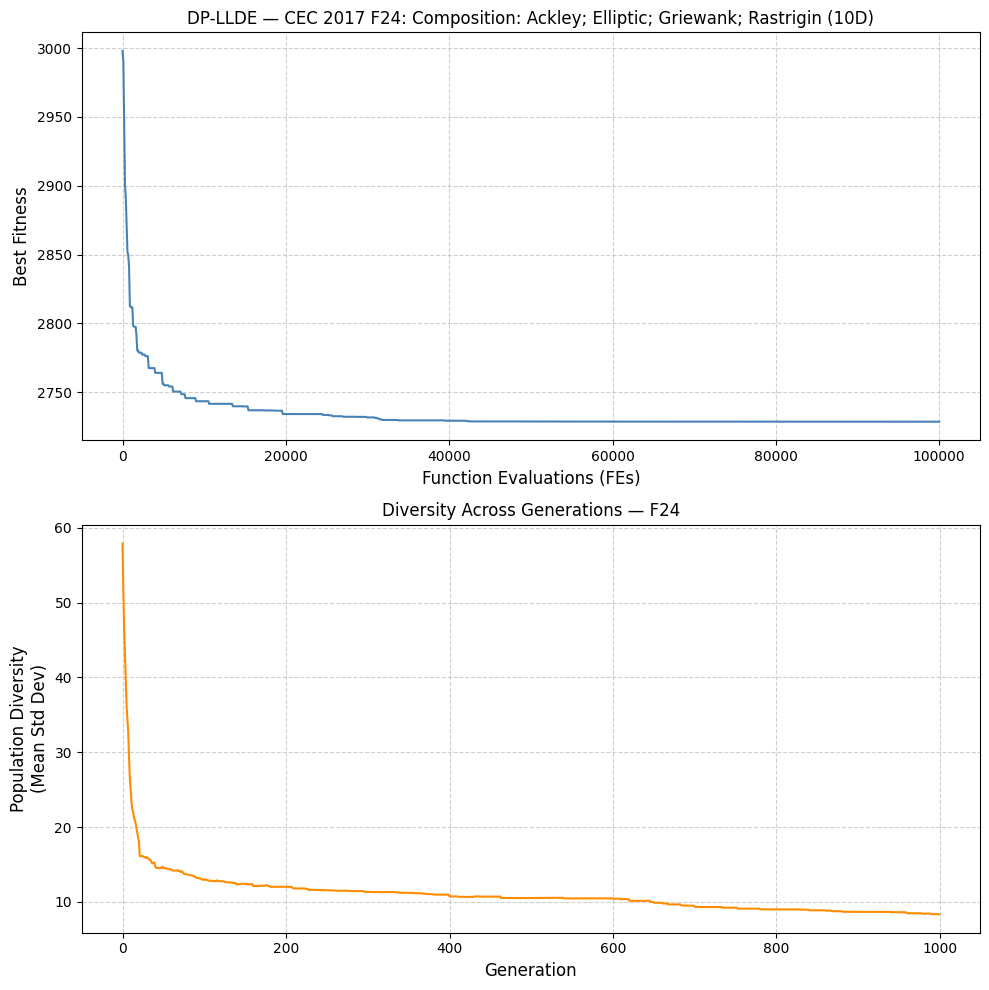

Graph saved as convergence_F24.png



In [38]:
# ============================================================
# F24 — Composition Function 4 (Ackley; Elliptic; Griewank; Rastrigin)
# ============================================================
run_and_plot('F24', make_wrapper(composition.f24), 2400.0, 'Composition: Ackley; Elliptic; Griewank; Rastrigin')

DP-LLDE on CEC 2017 F25 — Single Run
Function       : Composition: Rastrigin; HappyCat; Ackley; Discus; Rosenbrock (10D)
Bounds         : [-100, 100]
Global optimum : 2500.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 4.081798e+03
Generation   10: Best = 2.977029e+03  FES =   1100  μ_F = 0.572  μ_CR = 0.351  Diversity = 2.0240e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 2.948651e+03  FES =   2100  μ_F = 0.619  μ_CR = 0.356  Diversity = 6.4753e+00  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.945764e+03  FES =   3100  μ_F = 0.641  μ_CR = 0.364  Diversity = 2.6812e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.944735e+03  FES =   4100  μ_F = 0.660  μ_CR = 0.378  Diversity = 1.5435e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 2.944272e+03  FES =   5100  μ_F = 0.662  μ_CR = 0.368  Diversity = 1.0547e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 2.943808e+03  FES =   6100  μ_F = 0.662  μ_CR = 0.346  Diversity = 8.6036e-01  k_t = [

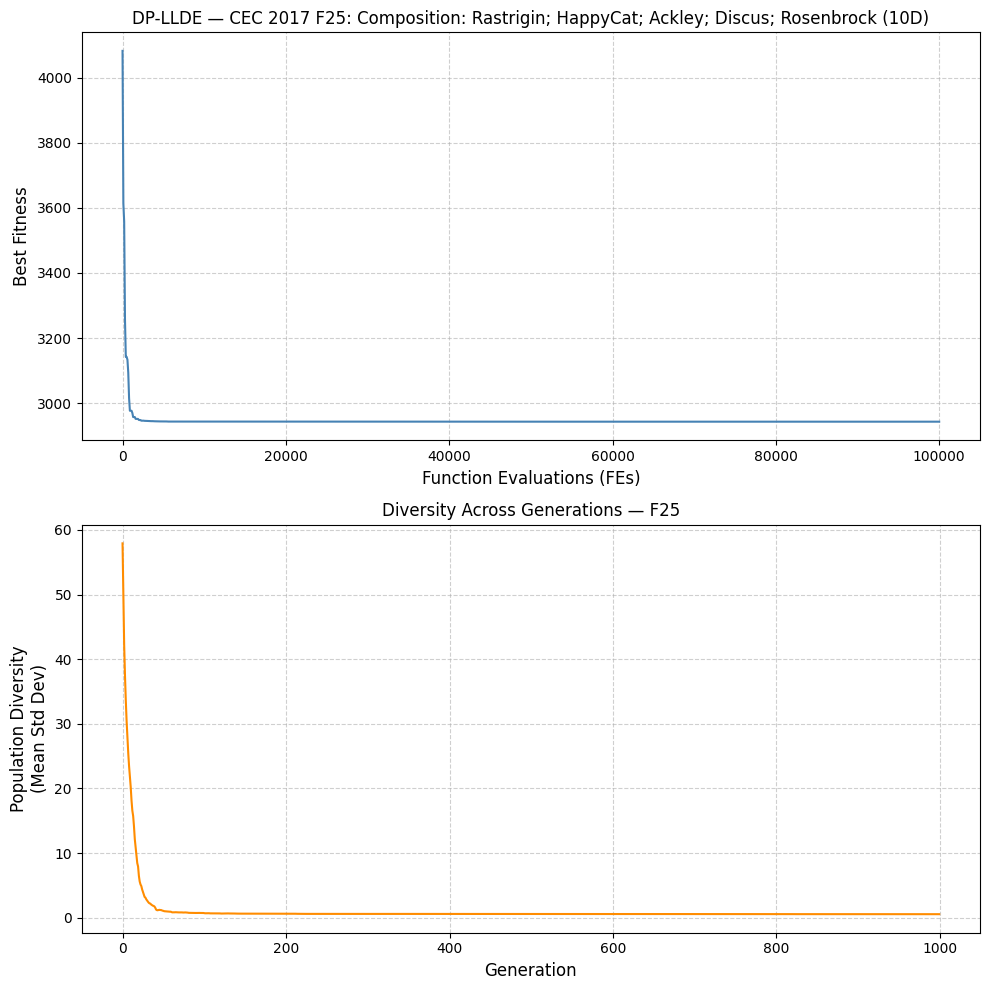

Graph saved as convergence_F25.png



In [39]:
# ============================================================
# F25 — Composition Function 5 (Rastrigin; HappyCat; Ackley; Discus; Rosenbrock)
# ============================================================
run_and_plot('F25', make_wrapper(composition.f25), 2500.0, 'Composition: Rastrigin; HappyCat; Ackley; Discus; Rosenbrock')

DP-LLDE on CEC 2017 F26 — Single Run
Function       : Composition: Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin (10D)
Bounds         : [-100, 100]
Global optimum : 2600.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 4.061684e+03
Generation   10: Best = 3.397413e+03  FES =   1100  μ_F = 0.571  μ_CR = 0.350  Diversity = 3.2254e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 3.081676e+03  FES =   2100  μ_F = 0.631  μ_CR = 0.352  Diversity = 1.0918e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 2.967309e+03  FES =   3100  μ_F = 0.671  μ_CR = 0.354  Diversity = 6.8081e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 2.914891e+03  FES =   4100  μ_F = 0.700  μ_CR = 0.359  Diversity = 3.8712e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 2.908524e+03  FES =   5100  μ_F = 0.722  μ_CR = 0.356  Diversity = 1.5815e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 2.903552e+03  FES =   6100  μ_F = 0.716  μ_CR = 0.355  Diversity = 7.3544e-01  k_t

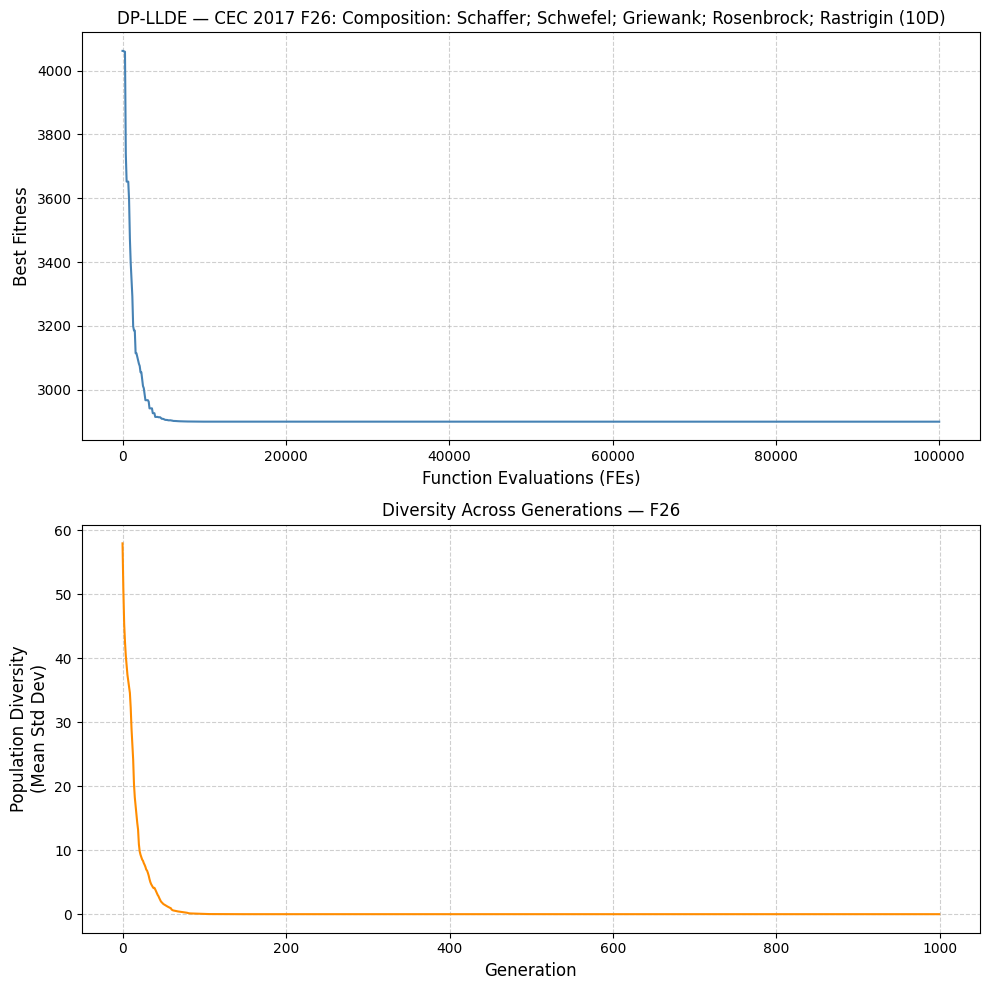

Graph saved as convergence_F26.png



In [40]:
# ============================================================
# F26 — Composition Function 6 (Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin)
# ============================================================
run_and_plot('F26', make_wrapper(composition.f26), 2600.0, 'Composition: Schaffer; Schwefel; Griewank; Rosenbrock; Rastrigin')

DP-LLDE on CEC 2017 F27 — Single Run
Function       : Composition: HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2700.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.284356e+03
Generation   10: Best = 3.124749e+03  FES =   1100  μ_F = 0.588  μ_CR = 0.349  Diversity = 4.3346e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 3.102940e+03  FES =   2100  μ_F = 0.646  μ_CR = 0.354  Diversity = 1.5493e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 3.096732e+03  FES =   3100  μ_F = 0.685  μ_CR = 0.346  Diversity = 9.3682e+00  k_t = [1, 1, 1, 1]
Generation   40: Best = 3.095745e+03  FES =   4100  μ_F = 0.727  μ_CR = 0.345  Diversity = 7.4525e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 3.094239e+03  FES =   5100  μ_F = 0.726  μ_CR = 0.328  Diversity = 7.1983e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 3.092968e+03  FES =   6100  μ_F = 0.751  μ_CR = 0.291  Diversity = 6.7787e+

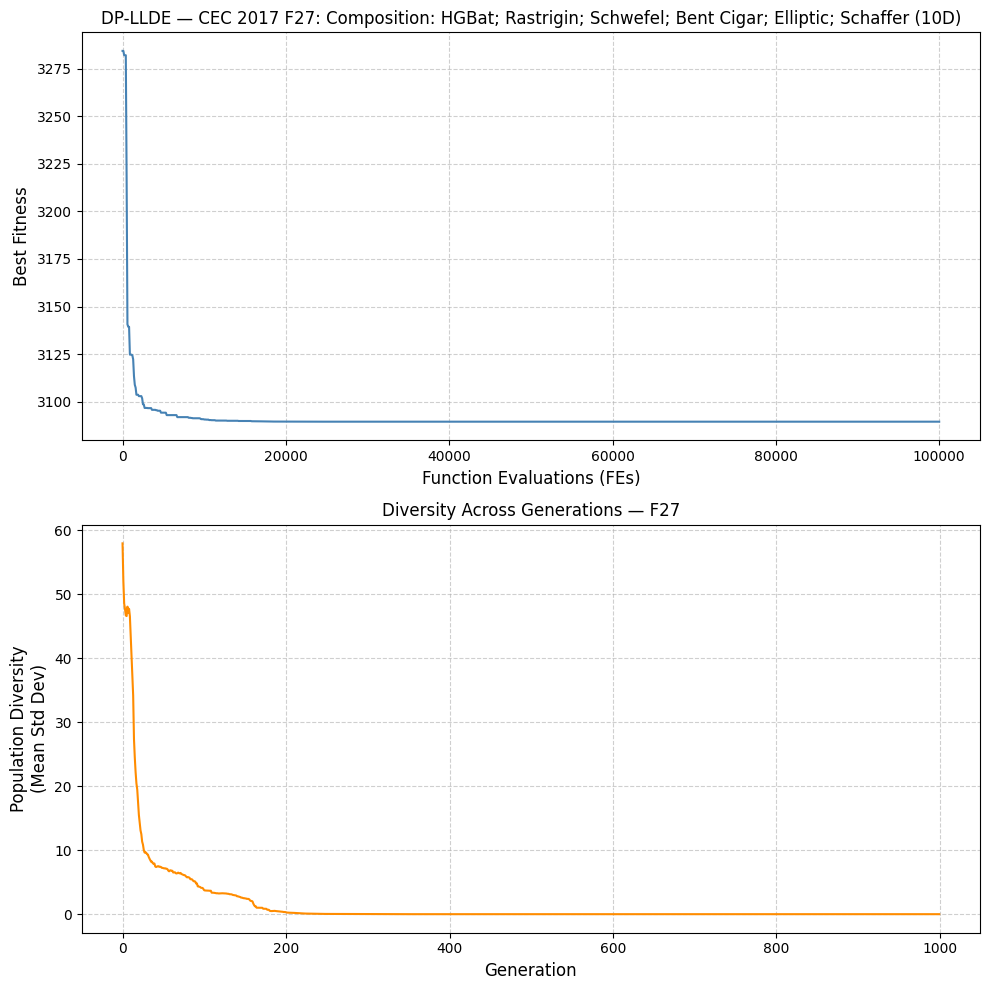

Graph saved as convergence_F27.png



In [41]:
# ============================================================
# F27 — Composition Function 7 (HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer)
# ============================================================
run_and_plot('F27', make_wrapper(composition.f27), 2700.0, 'Composition: HGBat; Rastrigin; Schwefel; Bent Cigar; Elliptic; Schaffer')

DP-LLDE on CEC 2017 F28 — Single Run
Function       : Composition: Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer (10D)
Bounds         : [-100, 100]
Global optimum : 2800.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 4.188047e+03
Generation   10: Best = 3.520386e+03  FES =   1100  μ_F = 0.568  μ_CR = 0.351  Diversity = 2.8889e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 3.270856e+03  FES =   2100  μ_F = 0.616  μ_CR = 0.348  Diversity = 2.8435e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 3.189122e+03  FES =   3100  μ_F = 0.663  μ_CR = 0.351  Diversity = 1.3269e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 3.175829e+03  FES =   4100  μ_F = 0.693  μ_CR = 0.361  Diversity = 5.3224e+00  k_t = [3, 3, 2, 4]
Generation   50: Best = 3.169058e+03  FES =   5100  μ_F = 0.710  μ_CR = 0.366  Diversity = 2.8406e+00  k_t = [1, 1, 1, 1]
Generation   60: Best = 3.166441e+03  FES =   6100  μ_F = 0.717  μ_CR = 0.350  Diversity = 2.3325e+00

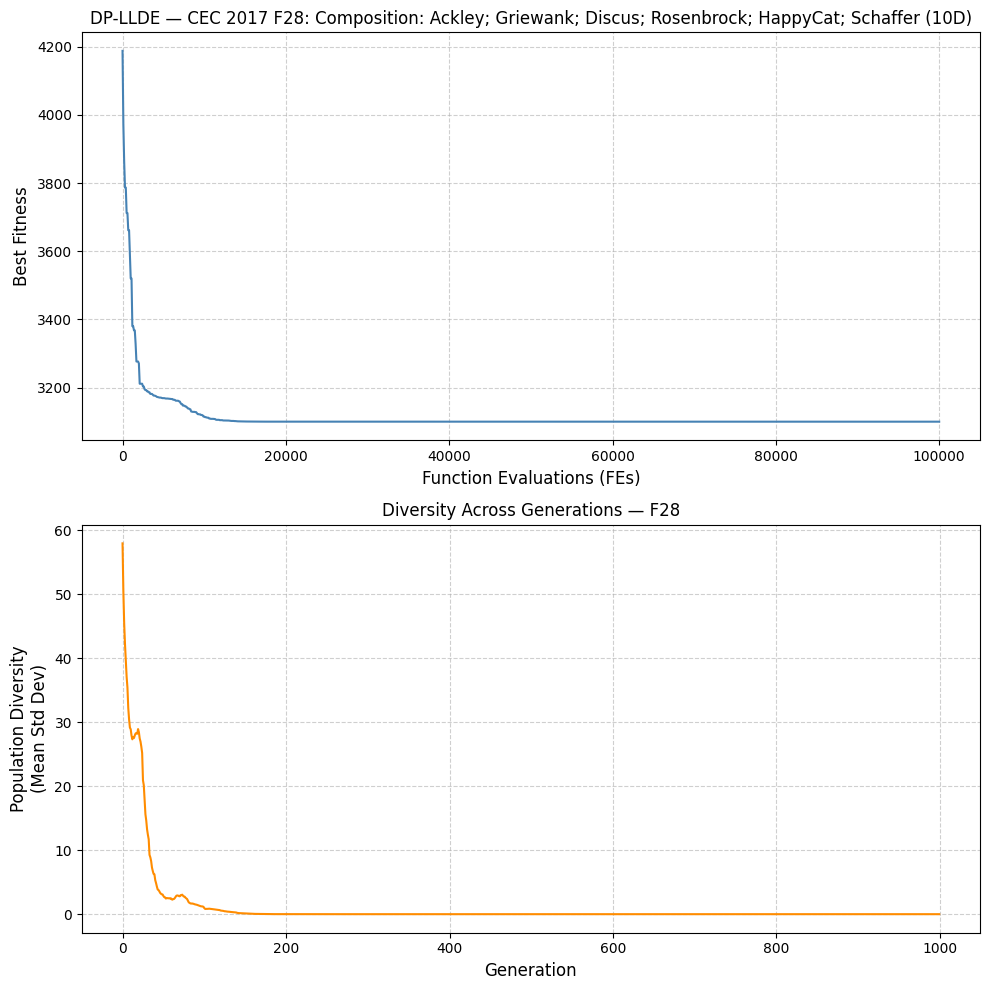

Graph saved as convergence_F28.png



In [42]:
# ============================================================
# F28 — Composition Function 8 (Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer)
# ============================================================
run_and_plot('F28', make_wrapper(composition.f28), 2800.0, 'Composition: Ackley; Griewank; Discus; Rosenbrock; HappyCat; Schaffer')

DP-LLDE on CEC 2017 F29 — Single Run
Function       : Composition: F15; F16; F17 (10D)
Bounds         : [-100, 100]
Global optimum : 2900.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 3.805371e+03
Generation   10: Best = 3.498177e+03  FES =   1100  μ_F = 0.580  μ_CR = 0.346  Diversity = 3.8537e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 3.328327e+03  FES =   2100  μ_F = 0.644  μ_CR = 0.336  Diversity = 3.8258e+01  k_t = [2, 4, 2, 2]
Generation   30: Best = 3.328327e+03  FES =   3100  μ_F = 0.700  μ_CR = 0.319  Diversity = 3.7333e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 3.310138e+03  FES =   4100  μ_F = 0.734  μ_CR = 0.327  Diversity = 3.5926e+01  k_t = [3, 4, 2, 3]
Generation   50: Best = 3.205632e+03  FES =   5100  μ_F = 0.741  μ_CR = 0.311  Diversity = 3.7670e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 3.205632e+03  FES =   6100  μ_F = 0.773  μ_CR = 0.268  Diversity = 3.5958e+01  k_t = [2, 4, 4, 4]
Generation   70: Best 

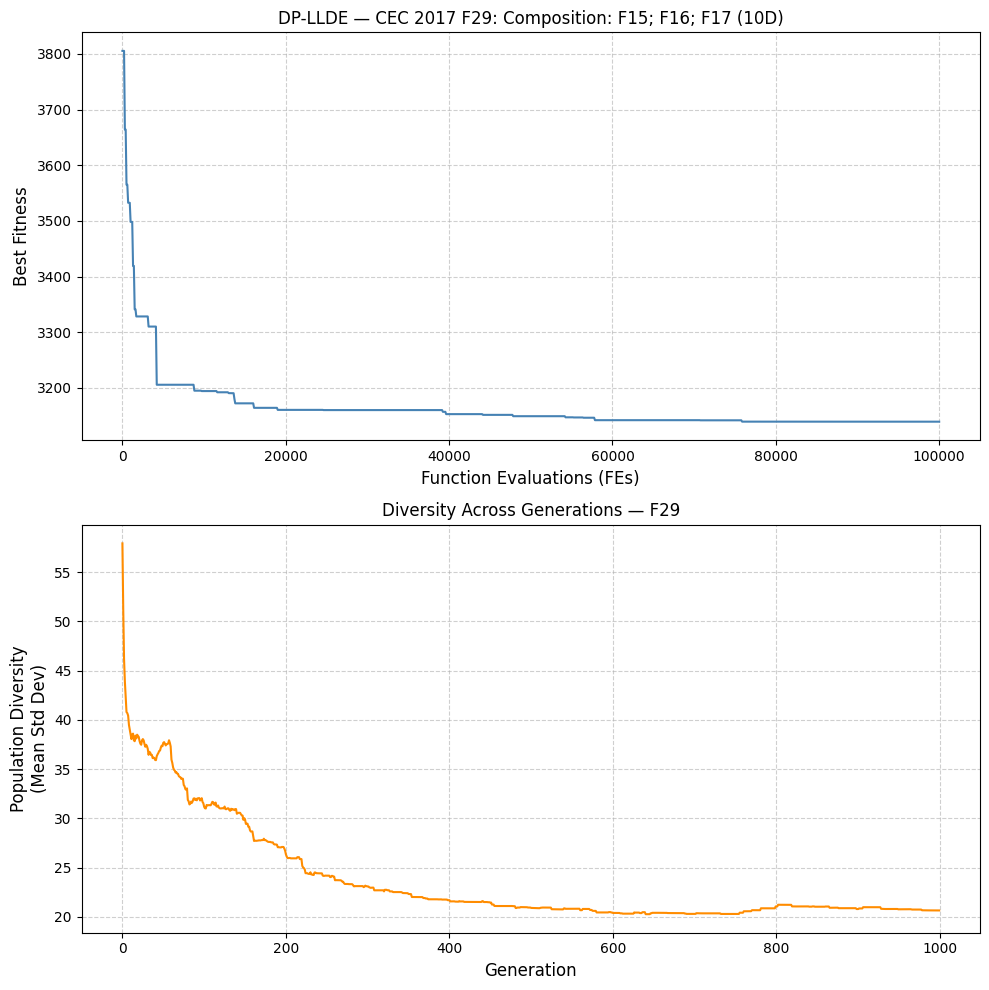

Graph saved as convergence_F29.png



In [43]:
# ============================================================
# F29 — Composition Function 9 (F15; F16; F17)
# ============================================================
run_and_plot('F29', make_wrapper(composition.f29), 2900.0, 'Composition: F15; F16; F17')

DP-LLDE on CEC 2017 F30 — Single Run
Function       : Composition: F15; F18; F19 (10D)
Bounds         : [-100, 100]
Global optimum : 3000.0
Initial D^(0) = 5.7928e+01  |  Diversity threshold = 5.7928e+00
Generation 0: Best Fitness = 1.165390e+08
Generation   10: Best = 2.119589e+07  FES =   1100  μ_F = 0.573  μ_CR = 0.336  Diversity = 4.4369e+01  k_t = [1, 1, 1, 1]
Generation   20: Best = 1.160791e+07  FES =   2100  μ_F = 0.630  μ_CR = 0.324  Diversity = 4.1194e+01  k_t = [3, 4, 2, 3]
Generation   30: Best = 1.949409e+06  FES =   3100  μ_F = 0.658  μ_CR = 0.276  Diversity = 3.9813e+01  k_t = [1, 1, 1, 1]
Generation   40: Best = 1.214605e+06  FES =   4100  μ_F = 0.694  μ_CR = 0.230  Diversity = 3.8664e+01  k_t = [3, 2, 4, 2]
Generation   50: Best = 9.126511e+05  FES =   5100  μ_F = 0.724  μ_CR = 0.217  Diversity = 3.6127e+01  k_t = [1, 1, 1, 1]
Generation   60: Best = 4.350937e+05  FES =   6100  μ_F = 0.764  μ_CR = 0.189  Diversity = 3.2302e+01  k_t = [2, 2, 4, 2]
Generation   70: Best 

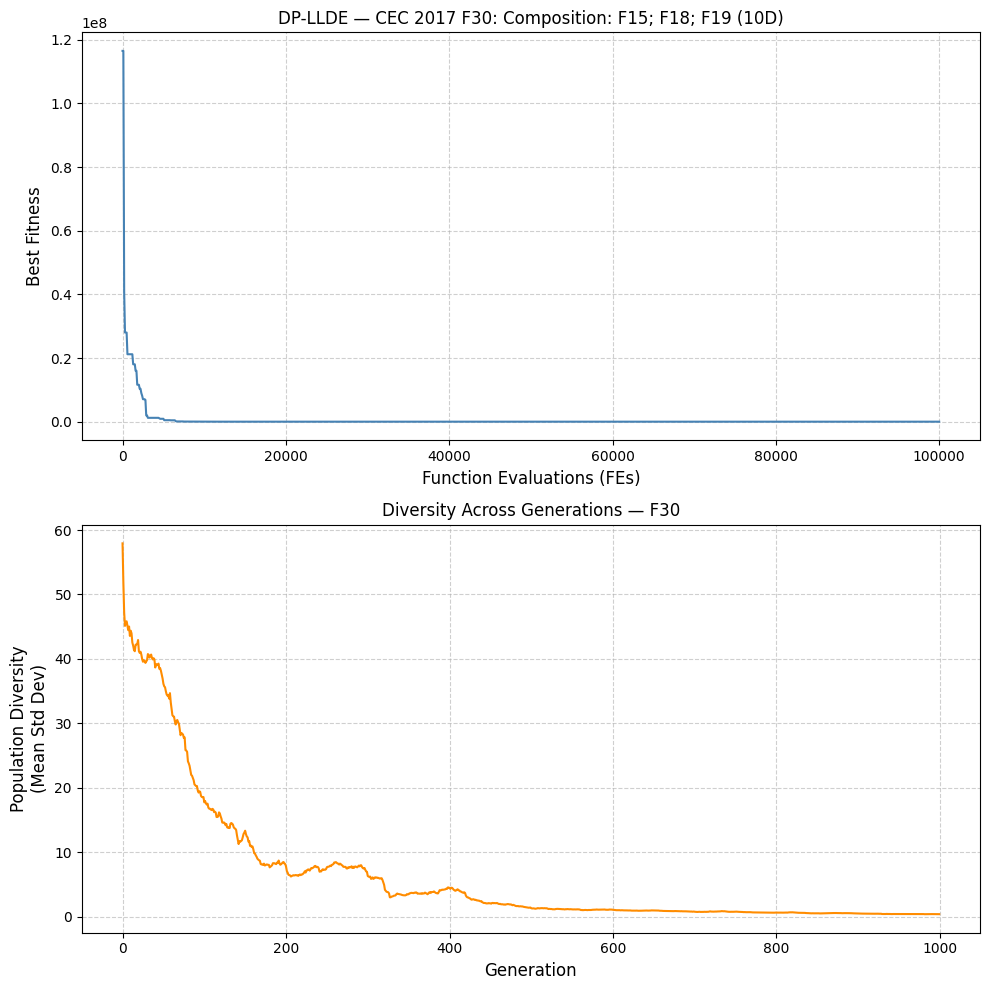

Graph saved as convergence_F30.png



In [44]:
# ============================================================
# F30 — Composition Function 10 (F15; F18; F19)
# ============================================================
run_and_plot('F30', make_wrapper(composition.f30), 3000.0, 'Composition: F15; F18; F19')

# ***Section 7. Compiled Results***

---



Print out a summary of all results in a tabular format

In [45]:
print('=' * 80)
print('SUMMARY — DP-LLDE on CEC 2017 (10D), Single Run, Seed=42')
print('=' * 80)
print(f'{"Function":<10} {"Best Fitness":>18} {"Global Optimum":>18} {"Error |best-opt|":>18}')
print('-' * 70)
for fn in [f'F{i}' for i in range(1, 31)]:
    if fn not in all_results:
        continue
    r = all_results[fn]
    if r['best_fit'] is None:
        print(f'{fn:<10} {"N/A (deprecated)":>18} {r["f_global"]:>18.2f} {"N/A":>18}')
    else:
        print(f'{fn:<10} {r["best_fit"]:>18.6e} {r["f_global"]:>18.2f} {r["error"]:>18.6e}')
print('=' * 80)

SUMMARY — DP-LLDE on CEC 2017 (10D), Single Run, Seed=42
Function         Best Fitness     Global Optimum   Error |best-opt|
----------------------------------------------------------------------
F1               1.000000e+02             100.00       1.421085e-14
F2               2.000001e+02             200.00       8.558419e-05
F3               3.000007e+02             300.00       6.879505e-04
F4               4.015519e+02             400.00       1.551874e+00
F5               5.022566e+02             500.00       2.256606e+00
F6               6.000000e+02             600.00       6.101186e-08
F7               7.120259e+02             700.00       1.202587e+01
F8               8.030705e+02             800.00       3.070500e+00
F9               9.000000e+02             900.00       0.000000e+00
F10              1.041861e+03            1000.00       4.186088e+01
F11              1.100000e+03            1100.00       8.412826e-11
F12              1.218469e+03            1200.00       1